In [ ]:
#@title Importación de librerías

# Manejo de rutas y memoria caché
from pathlib import Path
from joblib import Memory

# Manipulación y visualización de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from IPython.display import display

# Preprocesamiento
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier

# Balanceo y pipeline
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline

# Validación y búsqueda de hiperparámetros
from sklearn.model_selection import GridSearchCV, ParameterGrid

# Métricas
from sklearn.metrics import (
    make_scorer,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve
)

print("Librerías importadas correctamente.")

In [ ]:
#@title Configuración de rutas del proyecto

from pathlib import Path

directorio_actual = Path.cwd().resolve()

if directorio_actual.name == "notebooks":
    RUTA_PROYECTO = directorio_actual.parent

elif (directorio_actual / "notebooks").exists():
    RUTA_PROYECTO = directorio_actual

else:
    RUTA_PROYECTO = None

    for directorio_padre in directorio_actual.parents:
        if (
            (directorio_padre / "notebooks").exists()
            and (directorio_padre / "datos").exists()
        ):
            RUTA_PROYECTO = directorio_padre
            break

    if RUTA_PROYECTO is None:
        raise FileNotFoundError(
            "No se pudo encontrar la raíz del proyecto."
        )

RUTA_DATOS = (
    RUTA_PROYECTO
    / "datos"
)

RUTA_PREDICTIVO = (
    RUTA_DATOS
    / "03_predictivo"
)

# Regresión
RUTA_REGRESION = (
    RUTA_PREDICTIVO
    / "regresion"
)

RUTA_MODELOS = (
    RUTA_REGRESION
    / "models"
)

RUTA_RESULTADOS = (
    RUTA_REGRESION
    / "resultados"
)

# Clasificación
RUTA_CLASIFICACION = (
    RUTA_PREDICTIVO
    / "clasificacion"
)

RUTA_MODELOS_CLASIFICACION = (
    RUTA_CLASIFICACION
    / "models"
)

RUTA_RESULTADOS_CLASIFICACION = (
    RUTA_CLASIFICACION
    / "resultados"
)

rutas_crear = [
    RUTA_DATOS,
    RUTA_PREDICTIVO,
    RUTA_REGRESION,
    RUTA_MODELOS,
    RUTA_RESULTADOS,
    RUTA_CLASIFICACION,
    RUTA_MODELOS_CLASIFICACION,
    RUTA_RESULTADOS_CLASIFICACION
]

for ruta in rutas_crear:
    ruta.mkdir(
        parents=True,
        exist_ok=True
    )

print("Raíz del proyecto:")
print(RUTA_PROYECTO)

print("\nRegresión:")
print("Modelos:", RUTA_MODELOS)
print("Resultados:", RUTA_RESULTADOS)

print("\nClasificación:")
print("Modelos:", RUTA_MODELOS_CLASIFICACION)
print("Resultados:", RUTA_RESULTADOS_CLASIFICACION)

# 🔰 Problemática 1

**🚩 Problema predictivo 1: Regresión — Estimar la demanda mensual futura de cada producto según el canal de venta, la campaña comercial, el periodo y el comportamiento histórico de la demanda y los descuentos.**

Predicción de la cantidad de unidades demandadas por producto, categoría, subcategoría, marca, canal y campaña comercial.

**Pregunta de negocio:**

¿Cuántas unidades de cada producto se espera vender durante una campaña comercial determinada, en un mes y canal de venta específicos?

**Por ejemplo:**

¿Cuántas unidades del producto X se venderán por Web durante Cyber Wow Abril?

¿Cuál será la demanda del producto Y por App durante Navidad?

¿Cuántas unidades se espera vender en el canal Tienda durante un periodo normal de julio?

**Objetivo general**

Desarrollar y evaluar modelos predictivos de regresión que permitan estimar la cantidad de unidades demandadas de cada producto por campaña comercial, mes y canal de venta, utilizando las características del producto y el comportamiento histórico de la demanda y los descuentos.

**Variable objetivo:**

Demanda, medida como la cantidad total de unidades vendidas.

## 🚩 Carga y búsqueda de valores faltantes

In [ ]:
#@title Carga de CSV desde la carpeta datos

ruta_ventas = (
    RUTA_DATOS
    / "ventas.csv"
)

ruta_productos = (
    RUTA_DATOS
    / "productos.csv"
)

ruta_tiendas = (
    RUTA_DATOS
    / "tiendas.csv"
)

ruta_tickets = (
    RUTA_DATOS
    / "tickets.csv"
)

ruta_clientes = (
    RUTA_DATOS
    / "clientes.csv"
)

ruta_inventario = (
    RUTA_DATOS
    / "inventario.csv"
)

df_ventas = pd.read_csv(
    ruta_ventas,
    encoding="utf-8"
)

df_productos = pd.read_csv(
    ruta_productos,
    encoding="utf-8"
)

df_tiendas = pd.read_csv(
    ruta_tiendas,
    encoding="utf-8"
)

df_tickets = pd.read_csv(
    ruta_tickets,
    encoding="utf-8"
)

df_clientes = pd.read_csv(
    ruta_clientes,
    encoding="utf-8"
)

df_inventario = pd.read_csv(
    ruta_inventario,
    encoding="utf-8"
)

print("Archivos cargados correctamente.\n")

print("df_ventas:", df_ventas.shape)
print("df_productos:", df_productos.shape)
print("df_tiendas:", df_tiendas.shape)
print("df_tickets:", df_tickets.shape)
print("df_clientes:", df_clientes.shape)
print("df_inventario:", df_inventario.shape)

Archivos cargados correctamente.

df_ventas: (264967, 18)
df_productos: (1000, 8)
df_tiendas: (12, 7)
df_tickets: (100000, 14)
df_clientes: (15000, 15)
df_inventario: (432000, 9)


In [ ]:
#@title Información general de cada DataFrame
# Diccionario con todos los datasets cargados
datasets = {
    "Ventas": df_ventas,
    "Productos": df_productos,
    "Clientes": df_clientes,
    "Inventario": df_inventario,
    "Tickets": df_tickets,
    "Tiendas":df_tiendas,

}


for nombre, df in datasets.items():
    print("=" * 70)
    print(f"DATOS: {nombre.upper()}")
    print("=" * 70)
    df.info()
    print("\n")

DATOS: VENTAS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264967 entries, 0 to 264966
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id_venta         264967 non-null  int64  
 1   id_ticket        264967 non-null  object 
 2   fecha            264967 non-null  object 
 3   id_cliente       264967 non-null  int64  
 4   id_tienda        264967 non-null  int64  
 5   id_producto      264967 non-null  int64  
 6   cantidad         264967 non-null  int64  
 7   precio_unitario  264967 non-null  float64
 8   descuento_pct    261787 non-null  float64
 9   costo_unitario   264967 non-null  float64
 10  monto_total      264967 non-null  float64
 11  margen_unitario  264967 non-null  float64
 12  margen_total     264967 non-null  float64
 13  canal            264967 non-null  object 
 14  metodo_pago      260957 non-null  object 
 15  campaña          264967 non-null  object 
 16  es_campaña       264967 

In [ ]:
#@title Años que abarca el dataset de ventas

import pandas as pd

# Convertir la columna fecha a tipo datetime
df_ventas["fecha"] = pd.to_datetime(
    df_ventas["fecha"],
    errors="coerce"
)

# Obtener año mínimo y máximo
anio_inicio = df_ventas["fecha"].dt.year.min()
anio_fin = df_ventas["fecha"].dt.year.max()

print("Año inicial:", anio_inicio)
print("Año final:", anio_fin)
print(f"El dataset abarca desde {anio_inicio} hasta {anio_fin}.")

# Mostrar los años disponibles
print("\nAños presentes en el dataset:")
print(sorted(df_ventas["fecha"].dt.year.dropna().unique()))

Año inicial: 2023
Año final: 2025
El dataset abarca desde 2023 hasta 2025.

Años presentes en el dataset:
[np.int32(2023), np.int32(2024), np.int32(2025)]


In [ ]:
#@title Lista de campañas del dataset

campañas = sorted(df_ventas["campaña"].dropna().unique())

print("Campañas registradas:\n")

for campaña in campañas:
    print(f"- {campaña}")

Campañas registradas:

- Black Friday
- Campaña Escolar
- Cyber Wow Abril
- Cyber Wow Julio
- Cyber Wow Noviembre
- Día de la Madre
- Día del Padre
- Fiestas Patrias
- Navidad
- Normal


## 🚩 Valores faltantes e invalidos

In [ ]:
#@title Revisión de valores faltantes e inválidos en descuento_pct
#Se considera inválido un descuento menor que 0 o mayor que 0.35, porque el rango definido es de 0 % a 35 %.
faltantes_descuento = df_ventas["descuento_pct"].isna().sum()

invalidos_descuento = (
    (df_ventas["descuento_pct"] < 0)
    | (df_ventas["descuento_pct"] > 0.35)
).sum()

print("Revisión de descuento_pct")
print("-" * 40)
print("Valores faltantes:", faltantes_descuento)
print("Valores inválidos:", invalidos_descuento)

Revisión de descuento_pct
----------------------------------------
Valores faltantes: 3180
Valores inválidos: 0


In [ ]:
#@title Revisión de valores faltantes e inválidos en cantidad
#Se considera inválida una cantidad menor o igual que cero.
#Las cantidades mayores que 8 no se consideran inválidas, porque el dataset contiene algunos outliers controlados.

faltantes_cantidad = df_ventas["cantidad"].isna().sum()

invalidos_cantidad = (
    df_ventas["cantidad"] <= 0
).sum()

print("Revisión de cantidad")
print("-" * 40)
print("Valores faltantes:", faltantes_cantidad)
print("Valores inválidos:", invalidos_cantidad)

Revisión de cantidad
----------------------------------------
Valores faltantes: 0
Valores inválidos: 0


In [ ]:
#@title Revisión general de datos de ventas

faltantes_ventas = df_ventas.isna().sum()

invalidos_ventas = pd.Series({
    "fecha": df_ventas["fecha"].isna().sum(),
    "id_producto": (df_ventas["id_producto"] <= 0).sum(),
    "cantidad": (df_ventas["cantidad"] <= 0).sum(),
    "descuento_pct": (
        (df_ventas["descuento_pct"] < 0)
        | (df_ventas["descuento_pct"] > 0.35)
    ).sum(),
    "canal": (
        ~df_ventas["canal"].isin(["Tienda", "Web", "App"])
        & df_ventas["canal"].notna()
    ).sum(),
})

resumen_ventas = pd.DataFrame({
    "valores_faltantes": faltantes_ventas,
    "valores_invalidos": invalidos_ventas
}).fillna(0).astype(int)

print("Resumen de calidad de datos: ventas")
display(resumen_ventas)

Resumen de calidad de datos: ventas


,valores_faltantes,valores_invalidos
campaña,0,0
canal,0,0
cantidad,0,0
costo_unitario,0,0
descuento_pct,3180,0
es_campaña,0,0
fecha,0,0
id_cliente,0,0
id_producto,0,0
id_ticket,0,0


In [ ]:
#@title Revisión general de datos de productos

faltantes_productos = df_productos.isna().sum()

invalidos_productos = pd.Series({
    "id_producto": (
        (df_productos["id_producto"] <= 0).sum()
        + df_productos["id_producto"].duplicated().sum()
    ),
    "nombre": df_productos["nombre"].fillna("").str.strip().eq("").sum(),
    "categoria": df_productos["categoria"].fillna("").str.strip().eq("").sum(),
    "subcategoria": df_productos["subcategoria"].fillna("").str.strip().eq("").sum(),
    "marca": df_productos["marca"].fillna("").str.strip().eq("").sum(),
})

resumen_productos = pd.DataFrame({
    "valores_faltantes": faltantes_productos,
    "valores_invalidos": invalidos_productos
}).fillna(0).astype(int)

print("Resumen de calidad de datos: productos")
display(resumen_productos)

Resumen de calidad de datos: productos


,valores_faltantes,valores_invalidos
categoria,0,0
costo_unitario,0,0
fecha_alta,0,0
id_producto,0,0
marca,0,0
nombre,0,0
precio_lista,0,0
subcategoria,0,0


In [ ]:
#@title Cálculo de valores faltantes en descuento_pct

# Identificar únicamente los registros con descuento faltante
mascara_descuentento_faltante = df_ventas["descuento_pct"].isna()

print(
    "Descuentos faltantes antes del cálculo:",
    mascara_descuentento_faltante.sum()
)

# Calcular el descuento despejando la fórmula de monto_total
df_ventas.loc[
    mascara_descuentento_faltante,
    "descuento_pct"
] = (
    1
    - (
        df_ventas.loc[mascara_descuentento_faltante, "monto_total"]
        / (
            df_ventas.loc[mascara_descuentento_faltante, "cantidad"]
            * df_ventas.loc[mascara_descuentento_faltante, "precio_unitario"]
        )
    )
).round(4)

# Limitar posibles diferencias mínimas provocadas por el redondeo
df_ventas["descuento_pct"] = df_ventas["descuento_pct"].clip(
    lower=0,
    upper=0.35
)

# Verificación final
faltantes_finales = df_ventas["descuento_pct"].isna().sum()

invalidos_finales = (
    (df_ventas["descuento_pct"] < 0)
    | (df_ventas["descuento_pct"] > 0.35)
).sum()

print("\nVerificación final")
print("-" * 40)
print("Valores faltantes:", faltantes_finales)
print("Valores inválidos:", invalidos_finales)

print("\nResumen de descuento_pct:")
print(df_ventas["descuento_pct"].describe())

Descuentos faltantes antes del cálculo: 3180

Verificación final
----------------------------------------
Valores faltantes: 0
Valores inválidos: 0

Resumen de descuento_pct:
count    264967.000000
mean          0.099878
std           0.054015
min           0.000100
25%           0.061100
50%           0.088300
75%           0.127300
max           0.350000
Name: descuento_pct, dtype: float64


## 🚩 Selección de variables

 **Selección de variables de identificación**

| Variable | Dataset | Decisión | Motivo |
|---|---|---|---|
| `id_venta` | ventas.csv | **Eliminar** | Solo identifica una línea de venta y no aporta información útil para predecir la demanda. |
| `id_ticket` | ventas.csv | **Eliminar** | Únicamente permite relacionar varias líneas pertenecientes a una misma compra. |
| `id_cliente` | ventas.csv | **Eliminar** | Identifica al comprador y no corresponde al alcance del análisis producto–campaña. |
| `id_tienda` | ventas.csv | **Eliminar** | Identifica la tienda y sus caracteristicas. |
| `id_producto` | ventas.csv | **Conservar como clave** | Se necesita para agrupar las ventas y relacionarlas con la información de los productos. Sin embargo, no debe utilizarse como una variable numérica predictora. |
| `nombre` | producto.csv | **Conservar para mostrar resultados** | Permite identificar el producto en tablas, gráficos y reportes, pero no se utilizará necesariamente como variable predictora. |

**Variables que se originan después de la venta**
| Variable | Dataset | Decisión | Motivo |
|---|---|---|---|
| `metodo_pago` | ventas.csv | **Eliminar** | Se conoce al producirse la compra. |
| `monto_total` | ventas.csv | **Eliminar** | Esta variable se calcula a partir de la cantidad de productos comprados. |
| `margen_total` | ventas.csv | **Eliminar** | Esta variable se calcula a partir del monto total. |


**Otras Variables**
| Variable | Dataset | Decisión | Motivo |
|---|---|---|---|
| `es_campaña` | ventas.csv | **Eliminar** | Es redundante si se usa  `campaña` y `tipo_campaña`. |
| `margen_unitario` | ventas.csv | **Eliminar** | No explica la cantidad de demanda. |
| `precio_unitario` | ventas.csv | **Eliminar** | Corresponde al precio aplicado en una venta ya realizada. |
| `precio_lista` | ventas.csv | **Eliminar** | No explica la cantidad de demanda. |
| `costo_unitario` | ventas.csv / productos.csv | **Eliminar** | Es un dato interno relacionado con el margen y no con la decisión de compra del cliente, no explica la cantidad de demanda. |
| `fecha_alta` | productos.csv | **Eliminar** | La antiguedad del producto aporta muy poca información. |
| `fecha` | ventas.csv | **Trasformar** | A partir de ella se obtienen variables como `año` y `mes`, que estan asociados a las campañas. |
| `descuento_pcto` | ventas.csv | **Trasformar** | A partir de ella se obtienen variables como `descuento_promedio_periodo_anterior` y `descuento_promedio_misma_campaña_año_anterior`. |
| `cantidad` | venta.csv | **transformar** | Se obtiene la variable objetivo `demanda. |


**Variables Historicas**
| Variable | Dataset | Decisión | Motivo |
|---|---|---|---|
| `descuento_promedio_periodo_anterior` | Nuevo | **Generar** | A partir de `descuento_pcto`. |
| `descuento_promedio_misma_campaña_año_anterior` | Nuevo | **Generar** | A partir de `descuento_pcto`. |
| `demanda_campaña_anterior` | Nuevo | **Generar** | A partir de `cantidad`,`campaña`,`año`. |
| `demanda_misma_campaña_año_anterior` | Nuevo | **Generar** | A partir de `cantidad`,`campaña`,`año`. |

**Variables Historicas**
| Variable | Dataset | Decisión | Motivo |
|---|---|---|---|
| `demanda` | Nuevo | **Generar** | A partir de `cantidad`,`producto`,`canal`,`campaña`,`año` y `mes`. |


## 🚩 Eliminación y Transformación inicial de variables

In [ ]:
#@title Tabla Ventas
columnas_eliminar_ventas = [
    "id_venta",
    "id_ticket",
    "id_cliente",
    "id_tienda",
    "precio_unitario",
    "costo_unitario",
    "monto_total",
    "margen_unitario",
    "margen_total",
    "metodo_pago",
    "es_campaña",
]

df_ventas = df_ventas.drop(
    columns=columnas_eliminar_ventas,
    errors="ignore"
)

print("COLUMNAS RESTANTES: VENTAS")
print("=" * 70)
print(df_ventas.columns.tolist())
print("\nDimensión:", df_ventas.shape)

COLUMNAS RESTANTES: VENTAS
['fecha', 'id_producto', 'cantidad', 'descuento_pct', 'canal', 'campaña', 'tipo_campaña']

Dimensión: (264967, 7)


In [ ]:
#@title Tabla Productos

columnas_eliminar_productos = [
    "precio_lista",
    "costo_unitario",
    "fecha_alta",
]

df_productos = df_productos.drop(
    columns=columnas_eliminar_productos,
    errors="ignore"
)
print("COLUMNAS RESTANTES: PRODUCTOS")
print("=" * 70)
print(df_productos.columns.tolist())
print("\nDimensión:", df_productos.shape)

COLUMNAS RESTANTES: PRODUCTOS
['id_producto', 'nombre', 'categoria', 'subcategoria', 'marca']

Dimensión: (1000, 5)


In [ ]:
#@title Generación de variables año y mes

import pandas as pd

# Verificar que fecha sea de tipo datetime
df_ventas["fecha"] = pd.to_datetime(
    df_ventas["fecha"],
    errors="coerce"
)

# Diccionario de meses en español
nombres_meses = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre",
}

# Generar año
df_ventas["año"] = df_ventas["fecha"].dt.year

# Generar mes como nombre
df_ventas["mes"] = (
    df_ventas["fecha"]
    .dt.month
    .map(nombres_meses)
)

# Variable auxiliar mensual para cruces y ordenamiento
df_ventas["periodo"] = df_ventas["fecha"].dt.to_period("M")

# Convertir el mes en variable categórica nominal
df_ventas["mes"] = pd.Categorical(
    df_ventas["mes"],
    categories=list(nombres_meses.values()),
    ordered=False
)

# Verificación
print("Variables temporales generadas correctamente.\n")

display(
    df_ventas[
        [
            "fecha",
            "año",
            "mes",
            "campaña"
        ]
    ].head(10)
)

Variables temporales generadas correctamente.



,fecha,año,mes,campaña
0,2025-06-30,2025,Junio,Normal
1,2025-04-11,2025,Abril,Normal
2,2025-04-11,2025,Abril,Normal
3,2025-04-11,2025,Abril,Normal
4,2024-05-27,2024,Mayo,Normal
5,2024-03-06,2024,Marzo,Campaña Escolar
6,2024-03-06,2024,Marzo,Campaña Escolar
7,2023-12-28,2023,Diciembre,Navidad
8,2023-12-28,2023,Diciembre,Navidad
9,2024-12-18,2024,Diciembre,Navidad


## 🚩 Creación del dataframe para el entrenamiento

In [ ]:
#@title Creación del dataframe inicial de modelado

# Unir ventas con los datos de productos mediante id_producto
df_modelado = df_ventas.merge(
    df_productos,
    on="id_producto",
    how="left",
    validate="many_to_one"
)

print("DataFrame de modelado creado correctamente.")
print("Dimensión:", df_modelado.shape)

# Mostrar las primeras 10 filas
display(df_modelado.head(10))

DataFrame de modelado creado correctamente.
Dimensión: (264967, 14)


,fecha,id_producto,cantidad,descuento_pct,canal,campaña,tipo_campaña,año,mes,periodo,nombre,categoria,subcategoria,marca
0,2025-06-30,555,1,0.0729,Web,Normal,Regular,2025,Junio,2025-06,Monitores Andesol 349,Tecnología y Cómputo,Monitores,Andesol
1,2025-04-11,828,3,0.0776,App,Normal,Regular,2025,Abril,2025-04,Agua Altura 852,Bebidas,Agua,Altura
2,2025-04-11,478,2,0.0755,App,Normal,Regular,2025,Abril,2025-04,Botines Pacífico 041,Calzado,Botines,Pacífico
3,2025-04-11,588,1,0.0561,App,Normal,Regular,2025,Abril,2025-04,Botines Wayra 930,Calzado,Botines,Wayra
4,2024-05-27,321,2,0.0880,App,Normal,Regular,2024,Mayo,2024-05,Sandalias Tambo 514,Calzado,Sandalias,Tambo
5,2024-03-06,822,1,0.0333,Tienda,Campaña Escolar,Escolar,2024,Marzo,2024-03,Lavavajilla Kawsay 567,Limpieza,Lavavajilla,Kawsay
6,2024-03-06,294,1,0.0840,Tienda,Campaña Escolar,Escolar,2024,Marzo,2024-03,Botines Pacífico 612,Calzado,Botines,Pacífico
7,2023-12-28,510,5,0.0896,Tienda,Navidad,Festiva,2023,Diciembre,2023-12,Smartphones Wayra 133,Tecnología y Cómputo,Smartphones,Wayra
8,2023-12-28,73,1,0.0743,Tienda,Navidad,Festiva,2023,Diciembre,2023-12,Microondas SolRetail 073,Electrohogar,Microondas,SolRetail
9,2024-12-18,718,1,0.0913,Tienda,Navidad,Festiva,2024,Diciembre,2024-12,Freidora de Aire Killa 220,Electrohogar,Freidora de Aire,Killa


In [ ]:
#@title Creación de la demanda observada

columnas_agrupacion = [
    "id_producto",
    "canal",
    "campaña",
    "tipo_campaña",
    "año",
    "mes",
    "periodo"
]

df_demanda_observada = (
    df_modelado
    .groupby(
        columnas_agrupacion,
        as_index=False,
        observed=True,
        dropna=False
    )
    .agg(
        demanda=("cantidad", "sum"),
        descuento_promedio_periodo=("descuento_pct", "mean")
    )
)

df_demanda_observada["descuento_promedio_periodo"] = (
    df_demanda_observada["descuento_promedio_periodo"].round(4)
)

print("Demanda observada creada correctamente.")
print("Dimensión:", df_demanda_observada.shape)

display(df_demanda_observada.head(10))

Demanda observada creada correctamente.
Dimensión: (92700, 9)


,id_producto,canal,campaña,tipo_campaña,año,mes,periodo,demanda,descuento_promedio_periodo
0,1,App,Campaña Escolar,Escolar,2025,Marzo,2025-03,1,0.0794
1,1,App,Día de la Madre,Familiar,2025,Mayo,2025-05,3,0.1138
2,1,App,Día del Padre,Familiar,2025,Junio,2025-06,10,0.1058
3,1,App,Fiestas Patrias,Festiva,2024,Julio,2024-07,8,0.0867
4,1,App,Fiestas Patrias,Festiva,2025,Julio,2025-07,23,0.0930
5,1,App,Navidad,Festiva,2023,Diciembre,2023-12,10,0.0770
6,1,App,Navidad,Festiva,2024,Diciembre,2024-12,34,0.1088
7,1,App,Navidad,Festiva,2025,Diciembre,2025-12,37,0.1279
8,1,App,Normal,Regular,2023,Abril,2023-04,1,0.0750
9,1,App,Normal,Regular,2023,Mayo,2023-05,3,0.0542


In [ ]:
#@title Completar combinaciones sin ventas

# Productos disponibles
productos_base = (
    df_productos[["id_producto"]]
    .drop_duplicates()
)

# Canales disponibles
canales_base = (
    df_modelado[["canal"]]
    .drop_duplicates()
)

# Periodos comerciales existentes
periodos_comerciales = (
    df_modelado[
        [
            "periodo",
            "año",
            "mes",
            "campaña",
            "tipo_campaña"
        ]
    ]
    .drop_duplicates()
)

# Crear todas las combinaciones posibles
combinaciones_demanda = (
    productos_base
    .merge(canales_base, how="cross")
    .merge(periodos_comerciales, how="cross")
)

# Incorporar los valores realmente observados
df_demanda = combinaciones_demanda.merge(
    df_demanda_observada,
    on=[
        "id_producto",
        "canal",
        "campaña",
        "tipo_campaña",
        "año",
        "mes",
        "periodo"
    ],
    how="left",
    validate="one_to_one"
)

# Si la combinación existía, pero no hubo ventas
df_demanda["demanda"] = (
    df_demanda["demanda"]
    .fillna(0)
    .astype(int)
)

# Se adopta 0 cuando no hubo descuento observado por ausencia de ventas
df_demanda["descuento_promedio_periodo"] = (
    df_demanda["descuento_promedio_periodo"]
    .fillna(0)
    .round(4)
)

# Agregar características del producto
df_demanda = df_demanda.merge(
    df_productos,
    on="id_producto",
    how="left",
    validate="many_to_one"
)

print("Combinaciones sin ventas completadas correctamente.")
print("Dimensión final:", df_demanda.shape)

display(df_demanda.head(10))

Combinaciones sin ventas completadas correctamente.
Dimensión final: (162000, 13)


,id_producto,canal,periodo,año,mes,campaña,tipo_campaña,demanda,descuento_promedio_periodo,nombre,categoria,subcategoria,marca
0,1,Web,2025-06,2025,Junio,Normal,Regular,6,0.0619,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
1,1,Web,2025-04,2025,Abril,Normal,Regular,5,0.0318,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
2,1,Web,2024-05,2024,Mayo,Normal,Regular,0,0.0000,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
3,1,Web,2024-03,2024,Marzo,Campaña Escolar,Escolar,0,0.0000,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
4,1,Web,2023-12,2023,Diciembre,Navidad,Festiva,23,0.1146,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
5,1,Web,2024-12,2024,Diciembre,Navidad,Festiva,24,0.1128,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
6,1,Web,2025-02,2025,Febrero,Campaña Escolar,Escolar,1,0.0523,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
7,1,Web,2023-05,2023,Mayo,Día de la Madre,Familiar,0,0.0000,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
8,1,Web,2025-12,2025,Diciembre,Navidad,Festiva,40,0.0985,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara
9,1,Web,2025-05,2025,Mayo,Normal,Regular,0,0.0000,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara


In [ ]:
#@title Creación del historial mensual

df_historial_mensual = (
    df_modelado
    .groupby(
        [
            "id_producto",
            "canal",
            "periodo"
        ],
        as_index=False,
        observed=True
    )
    .agg(
        demanda_mes=("cantidad", "sum"),
        descuento_promedio_mes=("descuento_pct", "mean")
    )
)

df_historial_mensual["descuento_promedio_mes"] = (
    df_historial_mensual["descuento_promedio_mes"].round(4)
)

# Si no hubo ventas durante el mes
df_historial_mensual["demanda_mes"] = (
    df_historial_mensual["demanda_mes"]
    .fillna(0)
    .astype(int)
)

df_historial_mensual["descuento_promedio_mes"] = (
    df_historial_mensual["descuento_promedio_mes"]
    .fillna(0)
    .round(4)
)

In [ ]:
#@title Completar combinaciones mensuales sin ventas

productos = df_modelado["id_producto"].unique()
canales = df_modelado["canal"].dropna().unique()

periodos = pd.period_range(
    start=df_modelado["periodo"].min(),
    end=df_modelado["periodo"].max(),
    freq="M"
)

combinaciones_mensuales = pd.MultiIndex.from_product(
    [
        productos,
        canales,
        periodos
    ],
    names=[
        "id_producto",
        "canal",
        "periodo"
    ]
).to_frame(index=False)

df_historial_mensual = combinaciones_mensuales.merge(
    df_historial_mensual,
    on=[
        "id_producto",
        "canal",
        "periodo"
    ],
    how="left"
)

# Si no hubo ventas durante el mes, la demanda fue cero
df_historial_mensual["demanda_mes"] = (
    df_historial_mensual["demanda_mes"]
    .fillna(0)
    .astype(int)
)

# Si no hubo ventas, no hubo descuento observado
df_historial_mensual["descuento_promedio_mes"] = (
    df_historial_mensual["descuento_promedio_mes"]
    .fillna(0)
    .round(4)
)

print("Meses sin ventas completados correctamente.")
print("Dimensión:", df_historial_mensual.shape)

print("\nValores faltantes:")
print(
    df_historial_mensual[
        [
            "demanda_mes",
            "descuento_promedio_mes"
        ]
    ].isna().sum()
)

Meses sin ventas completados correctamente.
Dimensión: (108000, 5)

Valores faltantes:
demanda_mes               0
descuento_promedio_mes    0
dtype: int64


In [ ]:
#@title Creación de variables históricas del mes anterior

df_mes_anterior = df_historial_mensual.copy()

# El historial de un mes se asignará al mes siguiente
df_mes_anterior["periodo"] = (
    df_mes_anterior["periodo"] + 1
)

df_mes_anterior = df_mes_anterior.rename(
    columns={
        "demanda_mes": "demanda_mes_anterior",
        "descuento_promedio_mes":
            "descuento_promedio_mes_anterior"
    }
)

df_demanda = df_demanda.merge(
    df_mes_anterior[
        [
            "id_producto",
            "canal",
            "periodo",
            "demanda_mes_anterior",
            "descuento_promedio_mes_anterior"
        ]
    ],
    on=[
        "id_producto",
        "canal",
        "periodo"
    ],
    how="left"
)

print("Variables del mes anterior incorporadas correctamente.")

Variables del mes anterior incorporadas correctamente.


In [ ]:
#@title Variables históricas del mismo periodo del año anterior

columnas_anuales_existentes = [
    "demanda_misma_campaña_año_anterior",
    "descuento_promedio_misma_campaña_año_anterior"
]

df_demanda = df_demanda.drop(
    columns=columnas_anuales_existentes,
    errors="ignore"
)

df_historial_anual = df_demanda[
    [
        "id_producto",
        "canal",
        "campaña",
        "mes",
        "año",
        "demanda",
        "descuento_promedio_periodo"
    ]
].copy()

df_historial_anual["año"] = (
    df_historial_anual["año"] + 1
)

df_historial_anual = df_historial_anual.rename(
    columns={
        "demanda":
            "demanda_misma_campaña_año_anterior",
        "descuento_promedio_periodo":
            "descuento_promedio_misma_campaña_año_anterior"
    }
)

df_demanda = df_demanda.merge(
    df_historial_anual,
    on=[
        "id_producto",
        "canal",
        "campaña",
        "mes",
        "año"
    ],
    how="left"
)

print("Variables del mismo periodo del año anterior generadas.")

Variables del mismo periodo del año anterior generadas.


In [ ]:
df_demanda.head(10)

,id_producto,canal,periodo,año,mes,campaña,tipo_campaña,demanda,descuento_promedio_periodo,nombre,categoria,subcategoria,marca,demanda_mes_anterior,descuento_promedio_mes_anterior,demanda_misma_campaña_año_anterior,descuento_promedio_misma_campaña_año_anterior
0,1,Web,2025-06,2025,Junio,Normal,Regular,6,0.0619,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,8.0,0.0946,5.0,0.0904
1,1,Web,2025-04,2025,Abril,Normal,Regular,5,0.0318,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,1.0,0.0775,2.0,0.0498
2,1,Web,2024-05,2024,Mayo,Normal,Regular,0,0.0000,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,2.0,0.0498,8.0,0.0666
3,1,Web,2024-03,2024,Marzo,Campaña Escolar,Escolar,0,0.0000,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,1.0,0.0771,0.0,0.0000
4,1,Web,2023-12,2023,Diciembre,Navidad,Festiva,23,0.1146,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,9.0,0.1468,NaN,NaN
5,1,Web,2024-12,2024,Diciembre,Navidad,Festiva,24,0.1128,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,0.0,0.0000,23.0,0.1146
6,1,Web,2025-02,2025,Febrero,Campaña Escolar,Escolar,1,0.0523,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,9.0,0.0870,1.0,0.0771
7,1,Web,2023-05,2023,Mayo,Día de la Madre,Familiar,0,0.0000,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,6.0,0.0386,NaN,NaN
8,1,Web,2025-12,2025,Diciembre,Navidad,Festiva,40,0.0985,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,5.0,0.1026,24.0,0.1128
9,1,Web,2025-05,2025,Mayo,Normal,Regular,0,0.0000,Gaseosas Pukara 158,Bebidas,Gaseosas,Pukara,8.0,0.1316,0.0,0.0000


In [ ]:
#@title Cantidad de valores faltantes e inválidos por año

columnas_revision = [
    "demanda",
    "demanda_mes_anterior",
    "demanda_misma_campaña_año_anterior",
    "descuento_promedio_periodo",
    "descuento_promedio_mes_anterior",
    "descuento_promedio_misma_campaña_año_anterior"
]

# ============================================================
# VALORES FALTANTES POR AÑO
# ============================================================

faltantes_por_año = (
    df_demanda
    .groupby("año", observed=True)[columnas_revision]
    .apply(lambda grupo: grupo.isna().sum())
)

faltantes_por_año["total_faltantes"] = faltantes_por_año.sum(axis=1)

print("Valores faltantes por año")
display(faltantes_por_año)


# ============================================================
# VALORES INVÁLIDOS POR AÑO
# ============================================================

resultados_invalidos = []

for año, grupo in df_demanda.groupby("año", observed=True):

    resultados_invalidos.append({
        "año": año,

        # Las demandas no pueden ser negativas
        "demanda": (grupo["demanda"] < 0).sum(),
        "demanda_mes_anterior": (
            grupo["demanda_mes_anterior"] < 0
        ).sum(),
        "demanda_misma_campaña_año_anterior": (
            grupo["demanda_misma_campaña_año_anterior"] < 0
        ).sum(),

        # Los descuentos deben encontrarse entre 0 y 0.35
        "descuento_promedio_periodo": (
            (grupo["descuento_promedio_periodo"] < 0)
            | (grupo["descuento_promedio_periodo"] > 0.35)
        ).sum(),

        "descuento_promedio_mes_anterior": (
            (grupo["descuento_promedio_mes_anterior"] < 0)
            | (grupo["descuento_promedio_mes_anterior"] > 0.35)
        ).sum(),

        "descuento_promedio_misma_campaña_año_anterior": (
            (
                grupo[
                    "descuento_promedio_misma_campaña_año_anterior"
                ] < 0
            )
            | (
                grupo[
                    "descuento_promedio_misma_campaña_año_anterior"
                ] > 0.35
            )
        ).sum()
    })

invalidos_por_año = pd.DataFrame(resultados_invalidos).set_index("año")

invalidos_por_año["total_invalidos"] = (
    invalidos_por_año.sum(axis=1)
)

print("\nValores inválidos por año")
invalidos_por_año.head()

Valores faltantes por año


,demanda,demanda_mes_anterior,demanda_misma_campaña_año_anterior,descuento_promedio_periodo,descuento_promedio_mes_anterior,descuento_promedio_misma_campaña_año_anterior,total_faltantes
año,,,,,,,
2023,0,3000,54000,0,3000,54000,114000
2024,0,0,0,0,0,0,0
2025,0,0,0,0,0,0,0



Valores inválidos por año


,demanda,demanda_mes_anterior,demanda_misma_campaña_año_anterior,descuento_promedio_periodo,descuento_promedio_mes_anterior,descuento_promedio_misma_campaña_año_anterior,total_invalidos
año,,,,,,,
2023,0,0,0,0,0,0,0
2024,0,0,0,0,0,0,0
2025,0,0,0,0,0,0,0


In [ ]:
#@title Guardar dataset de demanda

ruta_dataset_demanda = (
    RUTA_PREDICTIVO
    / "dataset_demanda.csv"
)

df_demanda.to_csv(
    ruta_dataset_demanda,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset guardado correctamente.")
print("Ruta:", ruta_dataset_demanda.resolve())
print("Dimensiones:", df_demanda.shape)

Dataset guardado correctamente.
Ruta: /content/notebook03/dataset_demanda.csv
Dimensiones: (162000, 17)


## 🚩 Preparación para el entrenamiento

In [ ]:
#@title Eliminación de variables auxiliares

columnas_auxiliares = [
    "id_producto",                  # Redundante porque se utilizará nombre
    "periodo",                      # Solo se utilizó para cruces temporales
    "descuento_promedio_periodo",   # Pertenece al periodo actual
    "fecha_inicio",
    "fecha_fin",
]

df_demanda_modelo = df_demanda.drop(
    columns=columnas_auxiliares,
    errors="ignore"
).copy()

print("Variables auxiliares eliminadas correctamente.")
print("Dimensión:", df_demanda_modelo.shape)

print("\nColumnas conservadas:")
print(df_demanda_modelo.columns.tolist())

Variables auxiliares eliminadas correctamente.
Dimensión: (162000, 14)

Columnas conservadas:
['canal', 'año', 'mes', 'campaña', 'tipo_campaña', 'demanda', 'nombre', 'categoria', 'subcategoria', 'marca', 'demanda_mes_anterior', 'descuento_promedio_mes_anterior', 'demanda_misma_campaña_año_anterior', 'descuento_promedio_misma_campaña_año_anterior']


In [ ]:
#@title División temporal de entrenamiento y prueba

df_entrenamiento = (
    df_demanda_modelo[
        df_demanda_modelo["año"] == 2024
    ]
    .copy()
    .reset_index(drop=True)
)

df_prueba = (
    df_demanda_modelo[
        df_demanda_modelo["año"] == 2025
    ]
    .copy()
    .reset_index(drop=True)
)

print("División temporal realizada correctamente.")
print("-" * 50)
print("Entrenamiento 2024:", df_entrenamiento.shape)
print("Prueba 2025:", df_prueba.shape)

print("\nAños presentes en entrenamiento:")
print(df_entrenamiento["año"].value_counts())

print("\nAños presentes en prueba:")
print(df_prueba["año"].value_counts())

División temporal realizada correctamente.
--------------------------------------------------
Entrenamiento 2024: (54000, 14)
Prueba 2025: (54000, 14)

Años presentes en entrenamiento:
año
2024    54000
Name: count, dtype: int64

Años presentes en prueba:
año
2025    54000
Name: count, dtype: int64


In [ ]:
#@title One-Hot Encoding del conjunto de entrenamiento

import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder


# VARIABLES DEL MODELO

variables_categoricas = [
    "nombre",
    "categoria",
    "subcategoria",
    "marca",
    "canal",
    "campaña",
    "tipo_campaña",
    "mes",
]

variables_numericas = [
    "demanda_mes_anterior",
    "demanda_misma_campaña_año_anterior",
    "descuento_promedio_mes_anterior",
    "descuento_promedio_misma_campaña_año_anterior",
]

variable_objetivo = "demanda"

# CONFIGURAR Y AJUSTAR EL CODIFICADOR

codificador_one_hot = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True,
    dtype=np.uint8
)

matriz_categorica_entrenamiento = (
    codificador_one_hot.fit_transform(
        df_entrenamiento[variables_categoricas]
    )
)

nombres_columnas_one_hot = (
    codificador_one_hot.get_feature_names_out(
        variables_categoricas
    )
)


# CONVERTIR A DATAFRAME DISPERSO

df_categoricas_entrenamiento = (
    pd.DataFrame.sparse.from_spmatrix(
        matriz_categorica_entrenamiento,
        columns=nombres_columnas_one_hot,
        index=df_entrenamiento.index
    )
)

df_numericas_entrenamiento = (
    df_entrenamiento[variables_numericas]
    .astype(float)
    .copy()
)


# CREAR DATAFRAME TRANSFORMADO

df_entrenamiento_transformado = pd.concat(
    [
        df_numericas_entrenamiento,
        df_categoricas_entrenamiento
    ],
    axis=1
)

# Agregar la variable objetivo al final
df_entrenamiento_transformado[variable_objetivo] = (
    df_entrenamiento[variable_objetivo].to_numpy()
)

print("One-Hot Encoding aplicado al entrenamiento.")
print("Dimensión original:", df_entrenamiento.shape)
print(
    "Dimensión transformada:",
    df_entrenamiento_transformado.shape
)

display(df_entrenamiento_transformado.head())

One-Hot Encoding aplicado al entrenamiento.
Dimensión original: (54000, 14)
Dimensión transformada: (54000, 1136)


,demanda_mes_anterior,demanda_misma_campaña_año_anterior,descuento_promedio_mes_anterior,descuento_promedio_misma_campaña_año_anterior,nombre_Accesorios Ayni 016,nombre_Accesorios Ayni 622,nombre_Accesorios CostaSur 424,nombre_Accesorios InkaHome 105,nombre_Accesorios Nativa 118,nombre_Aceite Altura 560,...,mes_Enero,mes_Febrero,mes_Julio,mes_Junio,mes_Marzo,mes_Mayo,mes_Noviembre,mes_Octubre,mes_Septiembre,demanda
0,2.0,8.0,0.0498,0.0666,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,1.0,0.0,0.0771,0.0000,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0.0,23.0,0.0000,0.1146,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,24
3,2.0,0.0,0.0498,0.0000,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,2.0,0.0,0.0417,0.0000,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [ ]:
#@title One-Hot Encoding del conjunto de prueba


# TRANSFORMAR LAS VARIABLES CATEGÓRICAS


matriz_categorica_prueba = (
    codificador_one_hot.transform(
        df_prueba[variables_categoricas]
    )
)


# CONVERTIR A DATAFRAME DISPERSO


df_categoricas_prueba = (
    pd.DataFrame.sparse.from_spmatrix(
        matriz_categorica_prueba,
        columns=nombres_columnas_one_hot,
        index=df_prueba.index
    )
)

df_numericas_prueba = (
    df_prueba[variables_numericas]
    .astype(float)
    .copy()
)


# CREAR DATAFRAME TRANSFORMADO

df_prueba_transformado = pd.concat(
    [
        df_numericas_prueba,
        df_categoricas_prueba
    ],
    axis=1
)

# Agregar la variable objetivo real para la evaluación
df_prueba_transformado[variable_objetivo] = (
    df_prueba[variable_objetivo].to_numpy()
)

# Asegurar el mismo orden de columnas
df_prueba_transformado = df_prueba_transformado[
    df_entrenamiento_transformado.columns
]

print("One-Hot Encoding aplicado a prueba.")
print("Dimensión original:", df_prueba.shape)
print(
    "Dimensión transformada:",
    df_prueba_transformado.shape
)

print(
    "\nMismas columnas entre entrenamiento y prueba:",
    df_entrenamiento_transformado.columns.equals(
        df_prueba_transformado.columns
    )
)

display(df_prueba_transformado.head())

One-Hot Encoding aplicado a prueba.
Dimensión original: (54000, 14)
Dimensión transformada: (54000, 1136)

Mismas columnas entre entrenamiento y prueba: True


,demanda_mes_anterior,demanda_misma_campaña_año_anterior,descuento_promedio_mes_anterior,descuento_promedio_misma_campaña_año_anterior,nombre_Accesorios Ayni 016,nombre_Accesorios Ayni 622,nombre_Accesorios CostaSur 424,nombre_Accesorios InkaHome 105,nombre_Accesorios Nativa 118,nombre_Aceite Altura 560,...,mes_Enero,mes_Febrero,mes_Julio,mes_Junio,mes_Marzo,mes_Mayo,mes_Noviembre,mes_Octubre,mes_Septiembre,demanda
0,8.0,5.0,0.0946,0.0904,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,6
1,1.0,2.0,0.0775,0.0498,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
2,9.0,1.0,0.0870,0.0771,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
3,5.0,24.0,0.1026,0.1128,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,40
4,8.0,0.0,0.1316,0.0000,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


## 🚩 Entrenamiento

In [ ]:
#@title Separación de variables predictoras y variable objetivo

# Variables predictoras
X_entrenamiento = df_entrenamiento_transformado.drop(
    columns=[variable_objetivo]
).copy()

# Variable objetivo
y_entrenamiento = (
    df_entrenamiento_transformado[variable_objetivo]
    .copy()
)

print("Separación realizada correctamente.")
print("-" * 50)
print("Variables predictoras:", X_entrenamiento.shape)
print("Variable objetivo:", y_entrenamiento.shape)

print("\nVariable objetivo:")
print(y_entrenamiento.name)

print("\nCantidad de columnas predictoras:")
print(X_entrenamiento.shape[1])


Separación realizada correctamente.
--------------------------------------------------
Variables predictoras: (54000, 1135)
Variable objetivo: (54000,)

Variable objetivo:
demanda

Cantidad de columnas predictoras:
1135


In [ ]:
#@title Configuración de validación cruzada temporal

import numpy as np

SEMILLA = 2026

orden_meses = {
    "Enero": 1,
    "Febrero": 2,
    "Marzo": 3,
    "Abril": 4,
    "Mayo": 5,
    "Junio": 6,
    "Julio": 7,
    "Agosto": 8,
    "Septiembre": 9,
    "Octubre": 10,
    "Noviembre": 11,
    "Diciembre": 12,
}

# Verificar que los datos originales y transformados mantengan la misma cantidad de filas
assert len(df_entrenamiento) == len(X_entrenamiento) == len(y_entrenamiento)

# Número de mes utilizado únicamente para construir los folds
mes_numero_cv = (
    df_entrenamiento["mes"]
    .astype(str)
    .map(orden_meses)
)

if mes_numero_cv.isna().any():
    raise ValueError("Se encontraron meses no reconocidos en df_entrenamiento.")

configuracion_folds = [
    ("Fold 1", 1, 4, 5, 6),
    ("Fold 2", 1, 6, 7, 8),
    ("Fold 3", 1, 8, 9, 10),
    ("Fold 4", 1, 10, 11, 12),
]

cv_temporal = []

for nombre_fold, inicio_train, fin_train, inicio_validacion, fin_validacion in configuracion_folds:
    indices_train = np.flatnonzero(
        mes_numero_cv.between(inicio_train, fin_train).to_numpy()
    )

    indices_validacion = np.flatnonzero(
        mes_numero_cv.between(inicio_validacion, fin_validacion).to_numpy()
    )

    if len(indices_train) == 0 or len(indices_validacion) == 0:
        raise ValueError(f"{nombre_fold} no contiene suficientes registros.")

    cv_temporal.append(
        (indices_train, indices_validacion)
    )

# Métricas que serán calculadas durante GridSearchCV
metricas_cv = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

# Métrica utilizada para seleccionar y reajustar la mejor configuración
metrica_principal = "MAE"

print("Validación cruzada temporal configurada.")
print("Cantidad de folds:", len(cv_temporal))
print("Métrica principal:", metrica_principal)

for numero, (indices_train, indices_validacion) in enumerate(cv_temporal, start=1):
    meses_train = sorted(mes_numero_cv.iloc[indices_train].unique())
    meses_validacion = sorted(mes_numero_cv.iloc[indices_validacion].unique())

    print(
        f"Fold {numero}: "
        f"train meses {meses_train} ({len(indices_train)} registros) | "
        f"validación meses {meses_validacion} ({len(indices_validacion)} registros)"
    )

Validación cruzada temporal configurada.
Cantidad de folds: 4
Métrica principal: MAE
Fold 1: train meses [np.int64(1), np.int64(2), np.int64(3), np.int64(4)] (15000 registros) | validación meses [np.int64(5), np.int64(6)] (12000 registros)
Fold 2: train meses [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)] (27000 registros) | validación meses [np.int64(7), np.int64(8)] (9000 registros)
Fold 3: train meses [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)] (36000 registros) | validación meses [np.int64(9), np.int64(10)] (6000 registros)
Fold 4: train meses [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)] (42000 registros) | validación meses [np.int64(11), np.int64(12)] (12000 registros)


In [ ]:
#@title Diccionario de modelos e hiperparámetros

from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

modelos_parametros = {
    "Ridge Regression": {
        "modelo": Ridge(random_state=SEMILLA),
        "parametros": {
            "modelo__alpha": [0.1, 1.0, 10.0, 100.0],
            "modelo__solver": ["lsqr", "sag"],
        },
    },

    "Decision Tree": {
        "modelo": DecisionTreeRegressor(random_state=SEMILLA),
        "parametros": {
            "modelo__max_depth": [8, 16, None],
            "modelo__min_samples_split": [2, 10, 20],
            "modelo__min_samples_leaf": [1, 5, 10],
        },
    },

    "Random Forest": {
        "modelo": RandomForestRegressor(random_state=SEMILLA, n_jobs=1),
        "parametros": {
            "modelo__n_estimators": [200, 400],
            "modelo__max_depth": [12, 24],
            "modelo__min_samples_leaf": [3, 5],
            "modelo__max_features": ["sqrt", 0.5],
        },
    },

    "XGBoost": {
        "modelo": XGBRegressor(objective="reg:squarederror", random_state=SEMILLA, n_jobs=1, tree_method="hist"),
        "parametros": {
            "modelo__n_estimators": [200, 400],
            "modelo__learning_rate": [0.05, 0.10],
            "modelo__max_depth": [4, 7],
            "modelo__subsample": [0.8, 1.0],
        },
    },
}

print("Modelos configurados:", list(modelos_parametros.keys()))

for nombre_modelo, configuracion in modelos_parametros.items():
    cantidad_combinaciones = np.prod(
        [
            len(valores)
            for valores in configuracion["parametros"].values()
        ]
    )

    print(
        f"{nombre_modelo}: "
        f"{int(cantidad_combinaciones)} combinaciones"
    )

Modelos configurados: ['Ridge Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
Ridge Regression: 8 combinaciones
Decision Tree: 27 combinaciones
Random Forest: 16 combinaciones
XGBoost: 16 combinaciones


In [ ]:
#@title Creación de pipelines con escalamiento y modelo

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Columnas generadas por One-Hot Encoding
columnas_one_hot = [
    columna
    for columna in X_entrenamiento.columns
    if columna not in variables_numericas
]

# Escalar únicamente las variables numéricas
preprocesador_escalado = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            variables_numericas
        ),
        (
            "categoricas_one_hot",
            "passthrough",
            columnas_one_hot
        ),
    ],
    remainder="drop",
    sparse_threshold=1.0,
    verbose_feature_names_out=False,
)

pipelines_modelos = {}

for nombre_modelo, configuracion in modelos_parametros.items():
    pipelines_modelos[nombre_modelo] = Pipeline(
        steps=[
            (
                "escalador",
                clone(preprocesador_escalado)
            ),
            (
                "modelo",
                clone(configuracion["modelo"])
            ),
        ]
    )

print("Pipelines creados correctamente.")

for nombre_modelo, pipeline in pipelines_modelos.items():
    print(
        nombre_modelo,
        "→",
        list(pipeline.named_steps.keys())
    )

Pipelines creados correctamente.
Ridge Regression → ['escalador', 'modelo']
Decision Tree → ['escalador', 'modelo']
Random Forest → ['escalador', 'modelo']
XGBoost → ['escalador', 'modelo']


In [ ]:
#@title Entrenamiento y búsqueda de hiperparámetros

import pandas as pd

from sklearn.model_selection import GridSearchCV


resultados_busqueda = {}
mejores_modelos = {}
resumen_modelos = []


for nombre_modelo, configuracion in modelos_parametros.items():

    print("\n" + "-" * 70)
    print("Entrenando:", nombre_modelo)
    print("-" * 70)

    busqueda_grid = GridSearchCV(
        estimator=pipelines_modelos[nombre_modelo],
        param_grid=configuracion["parametros"],
        scoring=metricas_cv,
        refit=metrica_principal,
        cv=cv_temporal,
        n_jobs=-1,
        verbose=1,
        return_train_score=False,
        error_score="raise"
    )

    busqueda_grid.fit(
        X_entrenamiento,
        y_entrenamiento
    )

    # Resultados de validación cruzada
    resultados_cv = busqueda_grid.cv_results_
    indice_mejor = busqueda_grid.best_index_

    # Las métricas de error aparecen negativas en GridSearchCV
    mae_promedio = -resultados_cv["mean_test_MAE"][indice_mejor]
    rmse_promedio = -resultados_cv["mean_test_RMSE"][indice_mejor]
    r2_promedio = resultados_cv["mean_test_R2"][indice_mejor]

    desviacion_mae = resultados_cv["std_test_MAE"][indice_mejor]
    desviacion_rmse = resultados_cv["std_test_RMSE"][indice_mejor]
    desviacion_r2 = resultados_cv["std_test_R2"][indice_mejor]

    mejores_parametros = {
        parametro.replace("modelo__", ""): valor
        for parametro, valor in busqueda_grid.best_params_.items()
    }

    # Guardar el objeto completo de búsqueda
    resultados_busqueda[nombre_modelo] = busqueda_grid

    # Guardar el mejor pipeline reajustado con todo el entrenamiento
    mejores_modelos[nombre_modelo] = busqueda_grid.best_estimator_

    resumen_modelos.append(
        {
            "modelo": nombre_modelo,
            "MAE_CV": mae_promedio,
            "RMSE_CV": rmse_promedio,
            "R2_CV": r2_promedio,
            "desviacion_MAE": desviacion_mae,
            "desviacion_RMSE": desviacion_rmse,
            "desviacion_R2": desviacion_r2,
            "mejores_hiperparametros": mejores_parametros
        }
    )

    print("\nMejores hiperparámetros:")

    for parametro, valor in mejores_parametros.items():
        print(f"  {parametro}: {valor}")

    print("\nMejor resultado promedio de validación cruzada:")
    print(f"  MAE:  {mae_promedio:.4f} ± {desviacion_mae:.4f}")
    print(f"  RMSE: {rmse_promedio:.4f} ± {desviacion_rmse:.4f}")
    print(f"  R²:   {r2_promedio:.4f} ± {desviacion_r2:.4f}")
    print("  Refit final: Sí")


df_resultados_cv = (
    pd.DataFrame(resumen_modelos)
    .sort_values(
        by="MAE_CV",
        ascending=True
    )
    .reset_index(drop=True)
)

print("\nEntrenamiento de todos los modelos finalizado.")
print("Los modelos están ordenados desde el menor MAE.")

display(df_resultados_cv)


----------------------------------------------------------------------
Entrenando: Ridge Regression
----------------------------------------------------------------------
Fitting 4 folds for each of 8 candidates, totalling 32 fits

Mejores hiperparámetros:
  alpha: 100.0
  solver: lsqr

Mejor resultado promedio de validación cruzada:
  MAE:  3.4892 ± 0.6011
  RMSE: 5.7400 ± 1.5482
  R²:   0.3395 ± 0.2833
  Refit final: Sí

----------------------------------------------------------------------
Entrenando: Decision Tree
----------------------------------------------------------------------
Fitting 4 folds for each of 27 candidates, totalling 108 fits

Mejores hiperparámetros:
  max_depth: 8
  min_samples_leaf: 5
  min_samples_split: 2

Mejor resultado promedio de validación cruzada:
  MAE:  3.4888 ± 0.7634
  RMSE: 6.1532 ± 2.2856
  R²:   0.3290 ± 0.1860
  Refit final: Sí

----------------------------------------------------------------------
Entrenando: Random Forest
-------------------

,modelo,MAE_CV,RMSE_CV,R2_CV,desviacion_MAE,desviacion_RMSE,desviacion_R2,mejores_hiperparametros
0,Random Forest,3.453652,6.251448,0.345899,0.797476,2.610690,0.126173,"{'max_depth': 24, 'max_features': 0.5, 'min_sa..."
1,Decision Tree,3.488761,6.153223,0.328990,0.763364,2.285596,0.185957,"{'max_depth': 8, 'min_samples_leaf': 5, 'min_s..."
2,Ridge Regression,3.489216,5.740031,0.339530,0.601122,1.548246,0.283274,"{'alpha': 100.0, 'solver': 'lsqr'}"
3,XGBoost,3.511960,6.275481,0.342783,0.846314,2.670579,0.129174,"{'learning_rate': 0.05, 'max_depth': 7, 'n_est..."


## 🚩 Prueba

In [ ]:
#@title Evaluación del mejor modelo con el conjunto de prueba

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Seleccionar el modelo con menor MAE en validación cruzada
nombre_mejor_modelo = (
    df_resultados_cv
    .loc[df_resultados_cv["MAE_CV"].idxmin(), "modelo"]
)

mejor_modelo = mejores_modelos[nombre_mejor_modelo]

# Separar variables predictoras y objetivo de prueba
X_prueba = df_prueba_transformado.drop(
    columns=[variable_objetivo]
).copy()

y_prueba = (
    df_prueba_transformado[variable_objetivo]
    .astype(float)
    .copy()
)

# Verificar que las columnas coincidan
if not X_entrenamiento.columns.equals(X_prueba.columns):
    raise ValueError(
        "Las columnas de entrenamiento y prueba no coinciden "
        "o no están en el mismo orden."
    )

# Generar predicciones
y_pred_mejor_modelo = mejor_modelo.predict(X_prueba)

# Calcular métricas
mae_prueba = mean_absolute_error(
    y_prueba,
    y_pred_mejor_modelo
)

rmse_prueba = np.sqrt(
    mean_squared_error(
        y_prueba,
        y_pred_mejor_modelo
    )
)

r2_prueba = r2_score(
    y_prueba,
    y_pred_mejor_modelo
)

predicciones_negativas = int(
    (y_pred_mejor_modelo < 0).sum()
)

# Crear tabla con el resultado final
df_resultado_mejor_modelo = pd.DataFrame([
    {
        "modelo": nombre_mejor_modelo,
        "MAE_prueba": mae_prueba,
        "RMSE_prueba": rmse_prueba,
        "R2_prueba": r2_prueba,
        "predicciones_negativas": predicciones_negativas
    }
])

print("Evaluación final sobre el conjunto de prueba 2025")
print("\nModelo seleccionado:", nombre_mejor_modelo)
print(f"MAE:  {mae_prueba:.4f}")
print(f"RMSE: {rmse_prueba:.4f}")
print(f"R²:   {r2_prueba:.4f}")
print("Predicciones negativas:", predicciones_negativas)

display(df_resultado_mejor_modelo)

Evaluación final sobre el conjunto de prueba 2025

Modelo seleccionado: Random Forest
MAE:  3.1798
RMSE: 5.2157
R²:   0.7089
Predicciones negativas: 0


,modelo,MAE_prueba,RMSE_prueba,R2_prueba,predicciones_negativas
0,Random Forest,3.179768,5.215714,0.708903,0


In [ ]:
#@title Comparación entre validación cruzada y prueba final

df_comparacion_mejor_modelo = (
    df_resultados_cv[
        [
            "modelo",
            "MAE_CV",
            "RMSE_CV",
            "R2_CV"
        ]
    ]
    .merge(
        df_resultado_mejor_modelo,
        on="modelo",
        how="inner"
    )
    .reset_index(drop=True)
)

display(df_comparacion_mejor_modelo)

,modelo,MAE_CV,RMSE_CV,R2_CV,MAE_prueba,RMSE_prueba,R2_prueba,predicciones_negativas
0,Random Forest,3.453652,6.251448,0.345899,3.179768,5.215714,0.708903,0


In [ ]:
#@title Dataset con predicciones individuales del mejor modelo

columnas_identificacion = [
    "nombre",
    "canal",
    "campaña",
    "año",
    "mes"
]

df_predicciones_prueba = (
    df_prueba[columnas_identificacion]
    .copy()
    .reset_index(drop=True)
)

df_predicciones_prueba["demanda_real"] = (
    y_prueba.to_numpy()
)

nombre_columna_prediccion = (
    "prediccion_"
    + nombre_mejor_modelo
    .lower()
    .replace(" ", "_")
)

df_predicciones_prueba[nombre_columna_prediccion] = (
    y_pred_mejor_modelo
)

df_predicciones_prueba["error_absoluto"] = (
    df_predicciones_prueba["demanda_real"]
    - df_predicciones_prueba[nombre_columna_prediccion]
).abs()

ruta_predicciones = (
    RUTA_RESULTADOS
    / "predicciones_random_forest_prueba_2025.csv"
)

df_predicciones_prueba.to_csv(
    ruta_predicciones,
    index=False,
    encoding="utf-8-sig"
)

print("Predicciones guardadas correctamente en:")
print(ruta_predicciones.resolve())

display(df_predicciones_prueba.head(10))

Predicciones guardadas correctamente en:
/content/datos/03_predictivo/regresion/resultados/predicciones_random_forest_prueba_2025.csv


,nombre,canal,campaña,año,mes,demanda_real,prediccion_random_forest,error_absoluto
0,Gaseosas Pukara 158,Web,Normal,2025,Junio,6.0,3.300993,2.699007
1,Gaseosas Pukara 158,Web,Normal,2025,Abril,5.0,3.499226,1.500774
2,Gaseosas Pukara 158,Web,Campaña Escolar,2025,Febrero,1.0,2.106317,1.106317
3,Gaseosas Pukara 158,Web,Navidad,2025,Diciembre,40.0,31.540273,8.459727
4,Gaseosas Pukara 158,Web,Normal,2025,Mayo,0.0,2.239302,2.239302
5,Gaseosas Pukara 158,Web,Día de la Madre,2025,Mayo,8.0,1.494129,6.505871
6,Gaseosas Pukara 158,Web,Cyber Wow Abril,2025,Abril,3.0,1.228493,1.771507
7,Gaseosas Pukara 158,Web,Normal,2025,Agosto,22.0,4.276089,17.723911
8,Gaseosas Pukara 158,Web,Fiestas Patrias,2025,Julio,34.0,36.852587,2.852587
9,Gaseosas Pukara 158,Web,Normal,2025,Enero,9.0,4.147296,4.852704


## 🚩 Guardar Modelo

In [ ]:
#@title Guardar artefacto de Random Forest

import joblib

nombre_modelo = "Random Forest"

if nombre_modelo not in mejores_modelos:
    raise KeyError(
        f"No se encontró '{nombre_modelo}' "
        "dentro de mejores_modelos."
    )

pipeline_final = (
    mejores_modelos[nombre_modelo]
)

ruta_modelo = (
    RUTA_MODELOS
    / "random_forest.pkl"
)

artefacto = {
    "nombre_modelo": nombre_modelo,

    "codificador_one_hot": codificador_one_hot,

    "nombres_columnas_one_hot": (
        nombres_columnas_one_hot.tolist()
    ),

    "variables_categoricas": (
        variables_categoricas
    ),

    "variables_numericas": (
        variables_numericas
    ),

    "variable_objetivo": (
        variable_objetivo
    ),

    "columnas_modelo": (
        X_entrenamiento.columns.tolist()
    ),

    "pipeline": pipeline_final,

    "mejores_hiperparametros": (
        resultados_busqueda[
            nombre_modelo
        ].best_params_
    ),

    "metrica_refit": (
        resultados_busqueda[
            nombre_modelo
        ].refit
    ),

    "mejor_mae_cv": (
        -resultados_busqueda[
            nombre_modelo
        ].best_score_
    ),
}

joblib.dump(
    artefacto,
    ruta_modelo,
    compress=3
)

print(
    "Artefacto de Random Forest "
    "guardado correctamente en:"
)

print(ruta_modelo.resolve())

Artefacto de Random Forest guardado correctamente en:
/content/notebook03/artefactos_ml/random_forest.pkl


## 🚩 Análisis de variables

### 💠 Feature importance

In [ ]:
#@title Preparación del modelo para el análisis de importancia

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

nombre_modelo_final = "Random Forest"

pipeline_final = mejores_modelos[nombre_modelo_final]

preprocesador_final = pipeline_final.named_steps["escalador"]
modelo_final = pipeline_final.named_steps["modelo"]

# Obtener los nombres en el mismo orden utilizado por el modelo
nombres_variables_transformadas = (
    preprocesador_final.get_feature_names_out()
)

print("Modelo analizado:", nombre_modelo_final)
print("Cantidad de variables:", len(nombres_variables_transformadas))
print("Cantidad de importancias:", len(modelo_final.feature_importances_))

assert len(nombres_variables_transformadas) == len(modelo_final.feature_importances_)

Modelo analizado: Random Forest
Cantidad de variables: 1135
Cantidad de importancias: 1135


In [ ]:
#@title Importancia de variables de Random Forest

df_importancia_variables = pd.DataFrame({
    "variable": nombres_variables_transformadas,
    "importancia": modelo_final.feature_importances_
})

df_importancia_variables = (
    df_importancia_variables
    .sort_values(by="importancia", ascending=False)
    .reset_index(drop=True)
)

df_importancia_variables["importancia_porcentaje"] = (
    df_importancia_variables["importancia"] * 100
)

display(df_importancia_variables.head(20))

,variable,importancia,importancia_porcentaje
0,demanda_misma_campaña_año_anterior,0.639776,63.977598
1,descuento_promedio_misma_campaña_año_anterior,0.053304,5.330379
2,campaña_Navidad,0.041811,4.181105
3,mes_Diciembre,0.032628,3.262774
4,categoria_Juguetería,0.029905,2.990492
5,demanda_mes_anterior,0.023539,2.353939
6,descuento_promedio_mes_anterior,0.022247,2.224737
7,canal_Tienda,0.019893,1.989307
8,tipo_campaña_Festiva,0.016752,1.675219
9,categoria_Escolar y Oficina,0.009448,0.944759


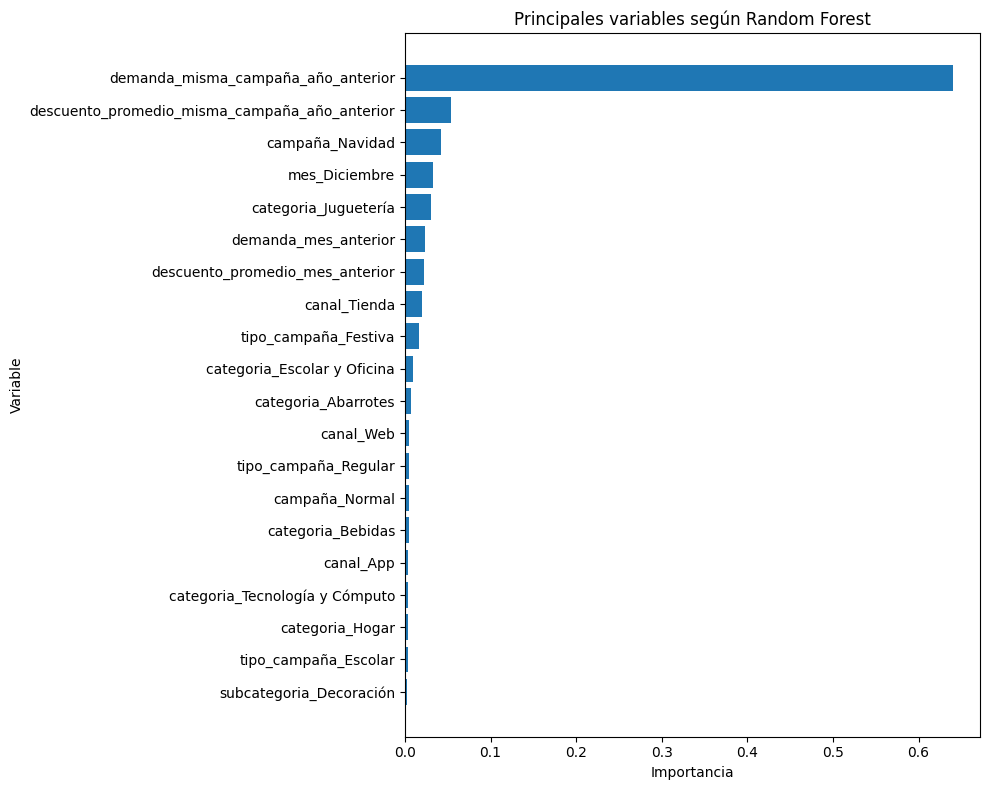

In [ ]:
#@title Gráfico de importancia de variables

top_importancia = (
    df_importancia_variables
    .head(20)
    .sort_values(by="importancia", ascending=True)
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_importancia["variable"],
    top_importancia["importancia"]
)

plt.title("Principales variables según Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [ ]:
#@title Importancia agrupada por variable original

def identificar_variable_original(nombre_variable):

    if nombre_variable in variables_numericas:
        return nombre_variable

    for variable in sorted(
        variables_categoricas,
        key=len,
        reverse=True
    ):
        if nombre_variable.startswith(f"{variable}_"):
            return variable

    return nombre_variable


df_importancia_variables["variable_original"] = (
    df_importancia_variables["variable"]
    .apply(identificar_variable_original)
)

df_importancia_agrupada = (
    df_importancia_variables
    .groupby("variable_original", as_index=False)["importancia"]
    .sum()
    .sort_values(by="importancia", ascending=False)
    .reset_index(drop=True)
)

df_importancia_agrupada["importancia_porcentaje"] = (
    df_importancia_agrupada["importancia"]
    / df_importancia_agrupada["importancia"].sum()
    * 100
)

display(df_importancia_agrupada)

,variable_original,importancia,importancia_porcentaje
0,demanda_misma_campaña_año_anterior,0.639776,63.977598
1,categoria,0.066726,6.672597
2,campaña,0.054564,5.456432
3,descuento_promedio_misma_campaña_año_anterior,0.053304,5.330379
4,mes,0.042285,4.228461
5,subcategoria,0.030857,3.085718
6,tipo_campaña,0.029300,2.930025
7,canal,0.028622,2.862187
8,demanda_mes_anterior,0.023539,2.353939
9,descuento_promedio_mes_anterior,0.022247,2.224737


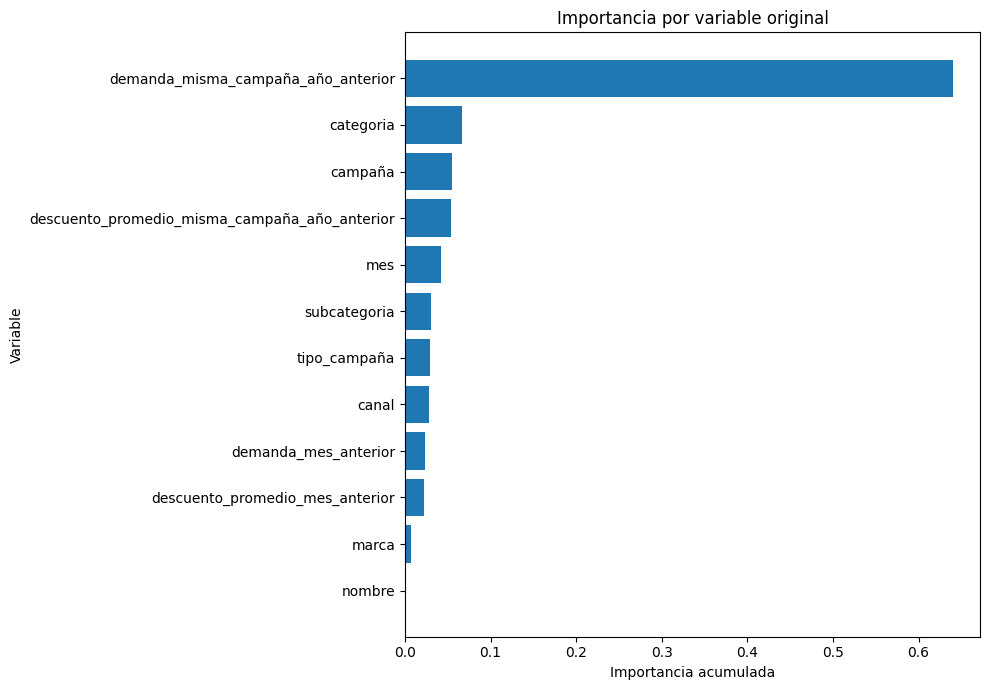

In [ ]:
#@title Gráfico de importancia agrupada

df_grafico_agrupado = (
    df_importancia_agrupada
    .sort_values(by="importancia", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    df_grafico_agrupado["variable_original"],
    df_grafico_agrupado["importancia"]
)

plt.title("Importancia por variable original")
plt.xlabel("Importancia acumulada")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### 💠 SHAP

In [ ]:
#@title Preparación de muestra para SHAP
import shap

from scipy import sparse

TAMANO_MUESTRA_SHAP = min(500, len(X_prueba))

X_muestra_shap = X_prueba.sample(
    n=TAMANO_MUESTRA_SHAP,
    random_state=SEMILLA
)

# Aplicar el mismo preprocesamiento utilizado por el modelo
X_muestra_transformada = preprocesador_final.transform(
    X_muestra_shap
)

# SHAP trabajará con una muestra densa manejable
if sparse.issparse(X_muestra_transformada):
    X_muestra_transformada = X_muestra_transformada.toarray()

df_X_muestra_shap = pd.DataFrame(
    X_muestra_transformada,
    columns=nombres_variables_transformadas,
    index=X_muestra_shap.index
)

print("Muestra utilizada:", df_X_muestra_shap.shape)

display(df_X_muestra_shap.head())

Muestra utilizada: (500, 1135)


,demanda_mes_anterior,demanda_misma_campaña_año_anterior,descuento_promedio_mes_anterior,descuento_promedio_misma_campaña_año_anterior,nombre_Accesorios Ayni 016,nombre_Accesorios Ayni 622,nombre_Accesorios CostaSur 424,nombre_Accesorios InkaHome 105,nombre_Accesorios Nativa 118,nombre_Aceite Altura 560,...,mes_Diciembre,mes_Enero,mes_Febrero,mes_Julio,mes_Junio,mes_Marzo,mes_Mayo,mes_Noviembre,mes_Octubre,mes_Septiembre
29053,-0.562238,0.453161,-1.167302,0.914515,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38217,0.021548,1.972838,1.697205,0.423800,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49946,-0.562238,0.127516,-1.167302,1.368635,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
40104,0.021548,-0.306677,-0.233060,0.415482,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
48179,-0.464940,0.236065,1.146771,0.699931,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
#@title Cálculo de valores SHAP

explicador_shap = shap.TreeExplainer(
    modelo_final
)

valores_shap = explicador_shap(
    df_X_muestra_shap
)

print("Valores SHAP calculados.")
print("Dimensión:", valores_shap.values.shape)

Valores SHAP calculados.
Dimensión: (500, 1135)


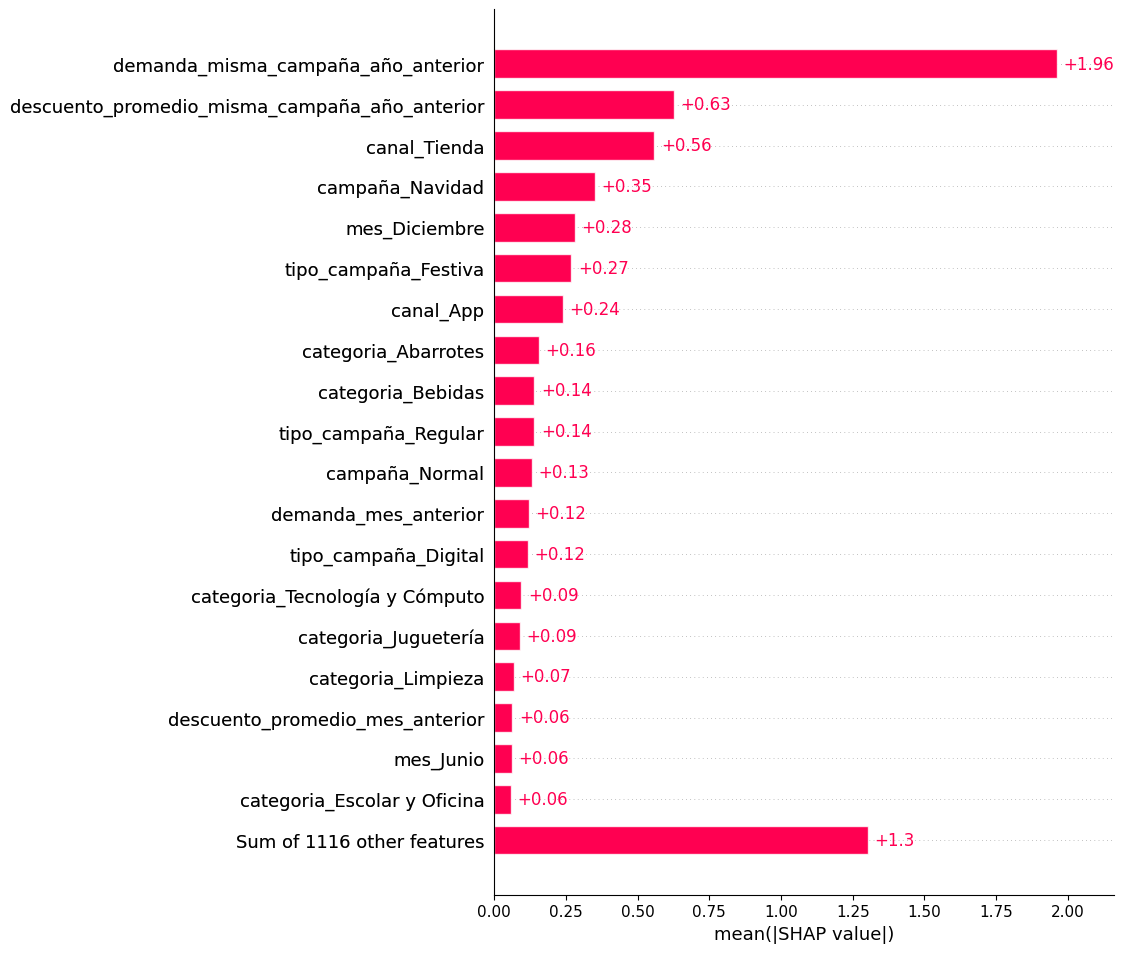

In [ ]:
#@title Importancia global mediante SHAP

shap.plots.bar(
    valores_shap,
    max_display=20
)

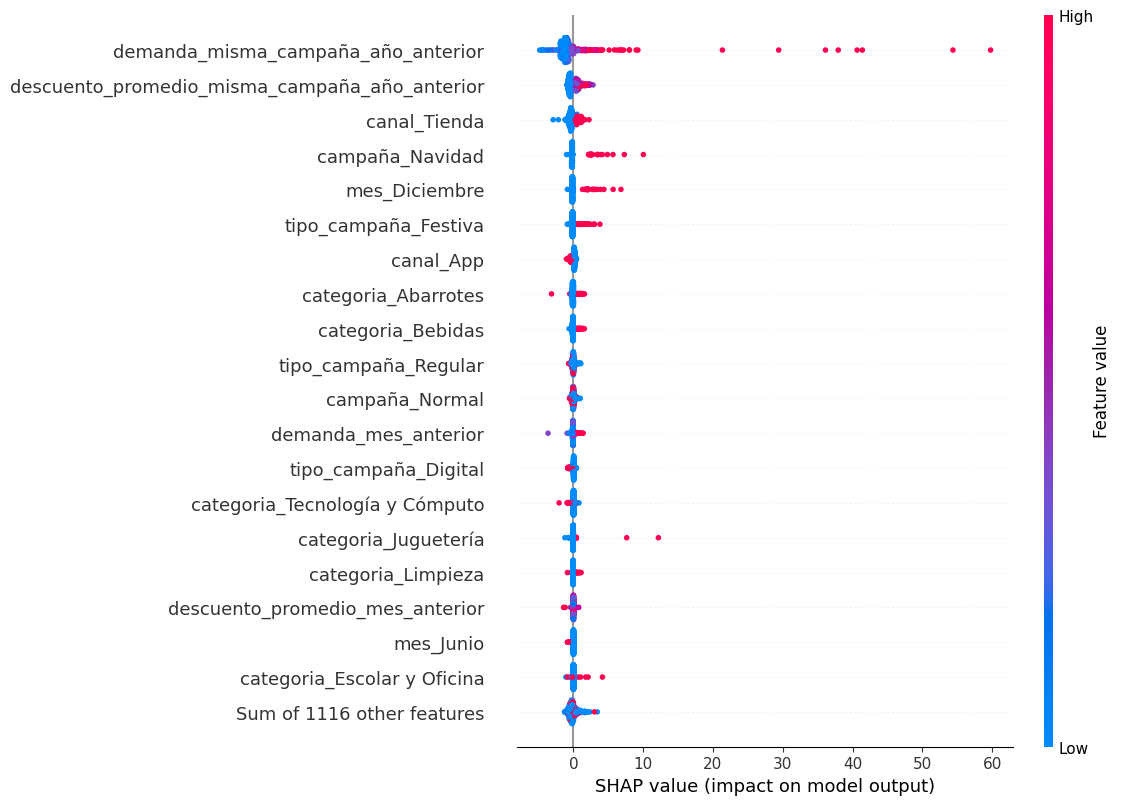

In [ ]:
#@title Impacto y dirección de variables mediante SHAP

shap.plots.beeswarm(
    valores_shap,
    max_display=20
)

In [ ]:
#@title Importancia SHAP agrupada por variable original

matriz_valores_shap = valores_shap.values

if matriz_valores_shap.ndim == 3:
    matriz_valores_shap = matriz_valores_shap[:, :, 0]

grupos_variables = {}

for posicion, nombre_variable in enumerate(nombres_variables_transformadas):

    variable_original = identificar_variable_original(
        nombre_variable
    )

    grupos_variables.setdefault(
        variable_original,
        []
    ).append(posicion)


importancias_shap_agrupadas = []

for variable_original, posiciones in grupos_variables.items():

    # Contribución conjunta de las columnas pertenecientes a una variable
    contribucion_variable = (
        matriz_valores_shap[:, posiciones]
        .sum(axis=1)
    )

    impacto_promedio = np.abs(
        contribucion_variable
    ).mean()

    importancias_shap_agrupadas.append({
        "variable": variable_original,
        "impacto_SHAP_promedio": impacto_promedio
    })


df_importancia_shap_agrupada = (
    pd.DataFrame(importancias_shap_agrupadas)
    .sort_values(
        by="impacto_SHAP_promedio",
        ascending=False
    )
    .reset_index(drop=True)
)

df_importancia_shap_agrupada["importancia_porcentaje"] = (
    df_importancia_shap_agrupada["impacto_SHAP_promedio"]
    / df_importancia_shap_agrupada["impacto_SHAP_promedio"].sum()
    * 100
)

display(df_importancia_shap_agrupada)

,variable,impacto_SHAP_promedio,importancia_porcentaje
0,demanda_misma_campaña_año_anterior,1.960694,36.294480
1,canal,0.725889,13.436951
2,descuento_promedio_misma_campaña_año_anterior,0.627119,11.608620
3,campaña,0.462652,8.564165
4,tipo_campaña,0.436885,8.087199
5,categoria,0.435782,8.066785
6,mes,0.332788,6.160254
7,subcategoria,0.179295,3.318944
8,demanda_mes_anterior,0.121610,2.251122
9,descuento_promedio_mes_anterior,0.062715,1.160925


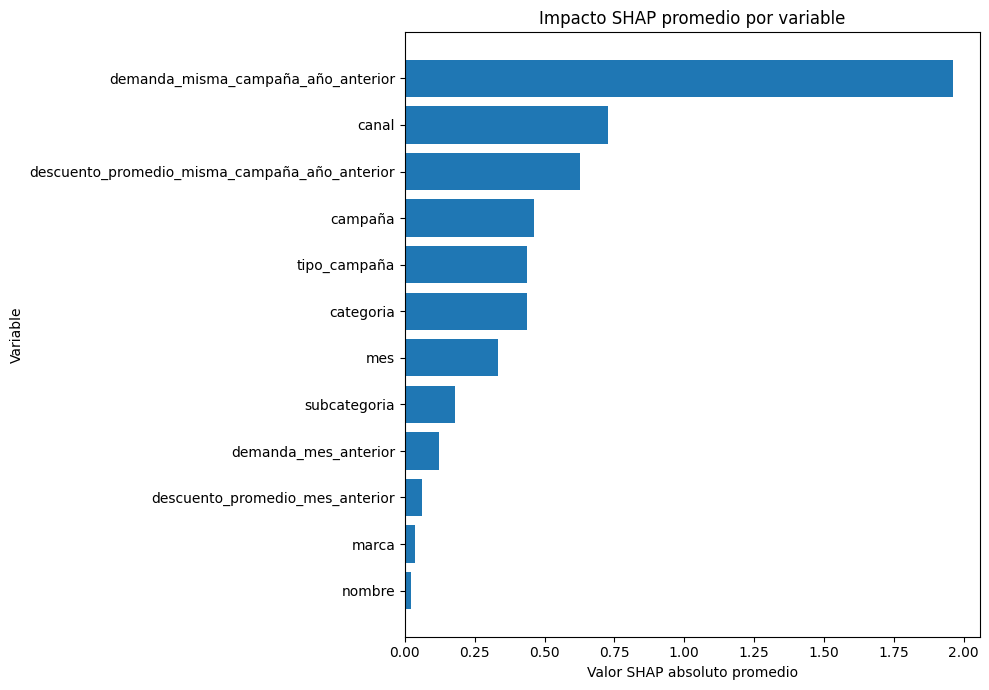

In [ ]:
#@title Gráfico SHAP por variable original

df_grafico_shap = (
    df_importancia_shap_agrupada
    .sort_values(
        by="impacto_SHAP_promedio",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    df_grafico_shap["variable"],
    df_grafico_shap["impacto_SHAP_promedio"]
)

plt.title("Impacto SHAP promedio por variable")
plt.xlabel("Valor SHAP absoluto promedio")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


Índice de la observación: 29053
Demanda real: 1.0
Demanda predicha: 2.867


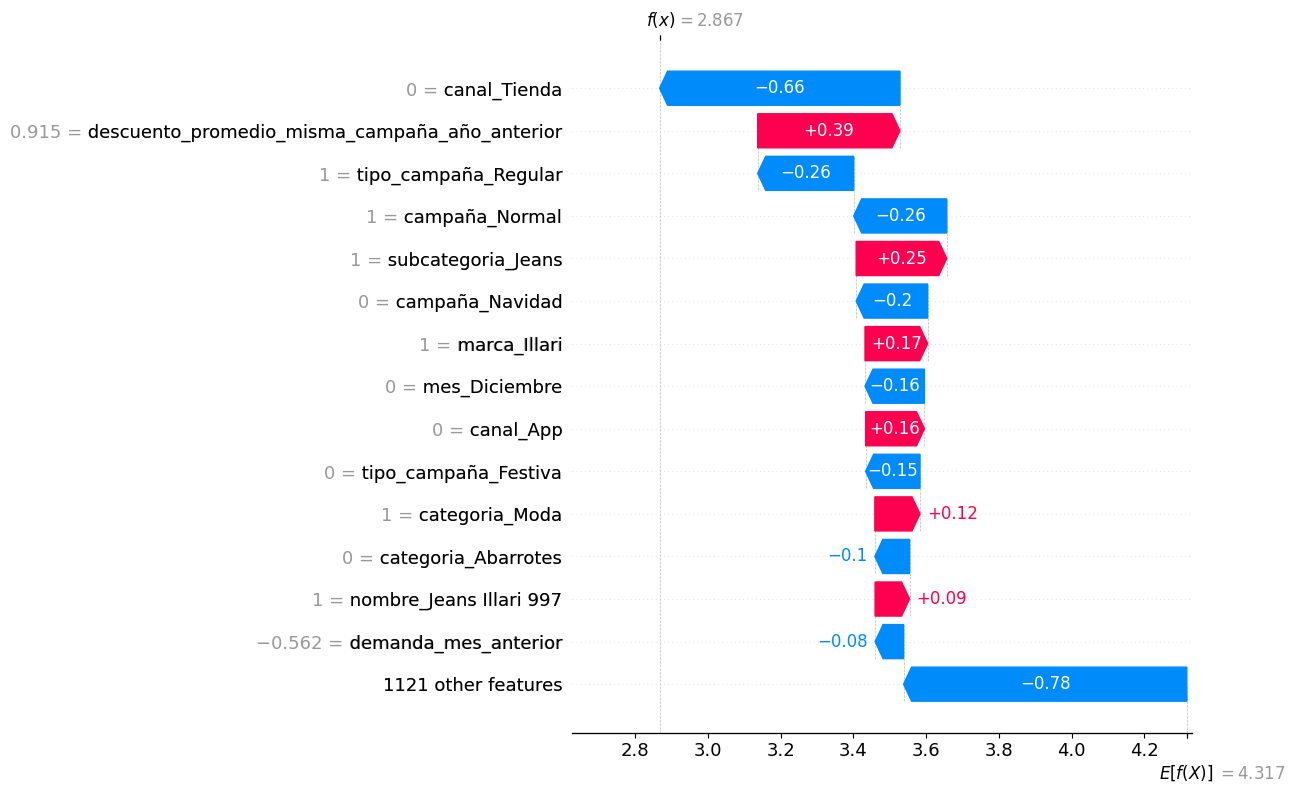

In [ ]:
#@title Explicación SHAP de una predicción individual

posicion_observacion = 0
indice_observacion = df_X_muestra_shap.index[posicion_observacion]

prediccion_observacion = modelo_final.predict(
    df_X_muestra_shap.iloc[[posicion_observacion]]
)[0]

demanda_real_observacion = y_prueba.loc[
    indice_observacion
]

print("Índice de la observación:", indice_observacion)
print("Demanda real:", demanda_real_observacion)
print("Demanda predicha:", round(prediccion_observacion, 4))

shap.plots.waterfall(
    valores_shap[posicion_observacion],
    max_display=15
)

In [ ]:
#@title Guardar resultados de importancia

df_importancia_variables.to_csv(
    RUTA_RESULTADOS
    / "importancia_detallada_random_forest.csv",
    index=False,
    encoding="utf-8-sig"
)

df_importancia_agrupada.to_csv(
    RUTA_RESULTADOS
    / "importancia_agrupada_random_forest.csv",
    index=False,
    encoding="utf-8-sig"
)

df_importancia_shap_agrupada.to_csv(
    RUTA_RESULTADOS
    / "importancia_shap_agrupada_random_forest.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Resultados guardados correctamente en:")
print(RUTA_RESULTADOS.resolve())

print("\nArchivos generados:")

for archivo in sorted(
    RUTA_RESULTADOS.iterdir()
):
    if archivo.is_file():
        print("-", archivo.name)

Resultados guardados correctamente en:
/content/notebook03/análisis_variables
- importancia_detallada_random_forest.csv
- importancia_shap_agrupada_random_forest.csv
- importancia_agrupada_random_forest.csv


**Interpretación**

El análisis de importancia de variables y valores SHAP mostró que la demanda registrada durante la misma campaña del año anterior fue el principal factor utilizado por Random Forest para estimar las ventas futuras. Asimismo, el canal de venta, los descuentos históricos, la campaña, el mes y la categoría del producto presentaron una influencia relevante sobre las predicciones. Estos resultados indican que la planificación de inventarios debe apoyarse principalmente en campañas comparables del año anterior, pero ajustando las cantidades según las condiciones comerciales y el canal en el que se espera realizar la venta. El modelo también evidenció que las campañas festivas, especialmente Navidad y diciembre, tienden a incrementar la demanda estimada, mientras que los periodos regulares presentan niveles más moderados.

## 🚩 Conclusiones y recomendaciones

**Conclusiones**

1. Los resultados muestran que Random Forest fue el modelo con mejor desempeño general. Alcanzó un MAE de 3.18 unidades, un RMSE de 5.22 y un R^2 de 0.7089 en el conjunto de prueba, por lo que logró estimar la demanda con mayor precisión que los demás modelos evaluados.

2. El modelo Random Forest logró explicar aproximadamente el 70.89 % de la variación observada en la demanda de 2025. Esto indica que las características del producto, la campaña, el canal de venta y el comportamiento histórico contienen información relevante para anticipar las unidades que podrían venderse.

3. El error promedio de aproximadamente 3.18 unidades representa un resultado favorable para la planificación comercial. Aunque no todas las predicciones serán exactas, el modelo puede servir como una referencia útil para estimar la cantidad de productos que deberían estar disponibles durante cada campaña y periodo.

4. XGBoost también presentó un desempeño competitivo, con un MAE de 3.25 y un R^2 de 0.6952. Sin embargo, Random Forest obtuvo mejores resultados tanto en la validación cruzada como en la prueba final, lo que respalda su selección como modelo principal.

5. Ridge Regression obtuvo el rendimiento más bajo y generó 457 predicciones negativas, las cuales no tienen una interpretación válida en términos de unidades vendidas. Este resultado demuestra que una relación únicamente lineal no representa por completo el comportamiento de la demanda, mientras que los modelos basados en árboles capturan mejor sus patrones.

**Recomendaciones**

1. Se recomienda utilizar Random Forest como modelo principal para apoyar la planificación de inventarios, debido a que presentó el menor error y la mayor capacidad para explicar la demanda en el conjunto de prueba.

2. Las predicciones deberían emplearse como una herramienta de apoyo y no como una cantidad definitiva de abastecimiento. La empresa puede complementar los resultados con el criterio del área comercial, el stock disponible, los tiempos de reposición y las condiciones particulares de cada campaña.

3. Se recomienda prestar mayor atención a los productos o periodos en los que el error sea considerablemente superior al promedio. El análisis de estos casos puede ayudar a identificar campañas atípicas, cambios inesperados en el comportamiento de los clientes o productos con una demanda especialmente variable.

4. El modelo debería actualizarse de manera periódica con nuevas ventas. A medida que se incorporen datos de campañas y periodos recientes, será posible adaptar las predicciones a cambios en las preferencias de los clientes, el crecimiento de los canales digitales y las nuevas condiciones comerciales.

5. Se recomienda complementar las métricas predictivas con el análisis de importancia de variables y valores SHAP. Esto permitirá comprender qué productos, campañas, canales, meses y antecedentes históricos influyen más en las estimaciones, facilitando decisiones de inventario y promociones más justificadas.

## notebook_03_predictivo (1)

<!-- merged from: notebook_03_predictivo (1).ipynb (Jupy Tools) -->

# 🔰 Problemática 2

🚩 Problma predictivo 2: Clasificación — Predecir la respuesta de los clientes a una campaña comercial según su comportamiento histórico de compra, el periodo y las características de la campaña.

Clasificación de los clientes según la probabilidad de realizar o no una compra durante una campaña comercial determinada.

Pregunta de negocio:

¿Un cliente realizará una compra durante una campaña comercial específica, considerando su comportamiento de compra anterior?

Por ejemplo:

¿El cliente X realizará una compra durante Cyber Wow Abril?

¿El cliente Y responderá a una campaña de Navidad?

¿Qué clientes tienen mayor probabilidad de comprar durante una campaña de Fiestas Patrias?

Objetivo general

Desarrollar y evaluar modelos predictivos de clasificación que permitan identificar si un cliente realizará una compra durante una campaña comercial determinada, utilizando su comportamiento histórico de compra y la información disponible antes del inicio de la campaña.

Variable objetivo:

respuesta_campaña, variable binaria que indica si el cliente realizó al menos una compra durante el periodo correspondiente a la campaña comercial evaluada.

0 = No respondió a la campaña: el cliente no realizó ninguna compra entre la fecha de inicio y la fecha de finalización de la campaña.
1 = Respondió a la campaña: el cliente realizó al menos una compra entre la fecha de inicio y la fecha de finalización de la campaña.

**Tablas seleccionadas:**

* clientes
* tickets
* ventas



## 🚩 Selección de variables

**Selección para la tabla cliente**

| Variable                   | Acción      | Justificación                                                                                                                                   |
| -------------------------- | ----------- | ----------------------------------------------------------------------------------------------------------------------------------------------- |
| `id_cliente`               | Conservar   | Es necesaria para relacionar cada cliente con los tickets y las campañas. Se utilizará como identificador, pero no ingresará como predictor.    |
| `nombre`                   | Eliminar    | Identifica personalmente al cliente, presenta alta cardinalidad y no aporta un patrón generalizable.                                            |
| `edad`                     | Conservar   | Puede contribuir a identificar diferencias generales en la respuesta a determinados tipos de campañas.                                          |
| `genero`                   | Conservar   | Puede evaluarse como característica demográfica. Posteriormente puede compararse el modelo con y sin esta variable.                             |
| `ciudad`                   | Conservar   | Permite identificar posibles diferencias de comportamiento comercial entre ciudades.                                                            |
| `distrito`                 | Eliminar    | Presenta mayor nivel de detalle, contiene valores faltantes y puede resultar redundante frente a `ciudad`.                                      |
| `fecha_registro`           | Transformar | Se convertirá a formato fecha para determinar si el cliente era elegible y calcular su antigüedad al inicio de cada campaña.                    |
| `canal_preferido`          | Eliminar    | Fue calculado utilizando el historial completo del cliente. No se reconstruirá porque no forma parte de las variables históricas seleccionadas. |
| `segmento`                 | Eliminar    | Se deriva del comportamiento acumulado del cliente y puede contener información posterior a la campaña evaluada.                                |
| `fecha_ultima_compra`      | Eliminar    | Puede contener compras posteriores a la campaña. La última compra válida se obtendrá directamente desde `TICKETS` antes de cada fecha de corte. |
| `frecuencia_tickets`       | Eliminar    | Resume todo el historial disponible. Será reemplazada por `tickets_previos_totales`, calculada antes de cada campaña.                           |
| `frecuencia_lineas`        | Eliminar    | Considera todas las líneas de compra del periodo y no forma parte de las variables históricas seleccionadas.                                    |
| `valor_total`              | Eliminar    | Acumula compras de todo el periodo y podría incluir información futura. No se utilizará en el enfoque seleccionado.                             |
| `dias_desde_ultima_compra` | Eliminar    | Se calculó con una fecha de corte general. Será reemplazada por `recencia_dias`, calculada para cada campaña.                                   |
| `churn`                    | Eliminar    | Corresponde a otro problema predictivo y puede contener información posterior a las campañas.                                                   |


**Selección para la tabla tickets**

| Variable                    | Acción      | Justificación                                                                                                                        |
| --------------------------- | ----------- | ------------------------------------------------------------------------------------------------------------------------------------ |
| `id_ticket`                 | Conservar   | Se utilizará para contar compras únicas realizadas antes o durante cada campaña. No será una variable predictora directa.            |
| `fecha`                     | Transformar | Se convertirá a formato fecha para ordenar los tickets, generar mes y año y separar la información histórica de la campaña evaluada. |
| `id_cliente`                | Conservar   | Permite relacionar cada ticket con el cliente correspondiente y construir sus indicadores históricos.                                |
| `id_tienda`                 | Eliminar    | Las características de la tienda no forman parte del alcance del modelo actual.                                                      |
| `canal`                     | Eliminar    | Aunque podría utilizarse históricamente, no forma parte de las variables seleccionadas para este modelo.                             |
| `metodo_pago`               | Eliminar    | No se utilizará para generar los indicadores históricos seleccionados y presenta valores faltantes.                                  |
| `campaña`                   | Conservar   | Permite identificar la campaña actual y localizar la misma campaña del año anterior.                                                 |
| `es_campaña`                | Transformar | Se utilizará para distinguir tickets de campañas y periodos normales. Después de realizar los filtros podrá retirarse.               |
| `tipo_campaña`              | Conservar   | Permite identificar campañas Digitales, Festivas, Familiares o Escolares y calcular los tickets previos del mismo tipo.              |
| `cantidad_lineas`           | Eliminar    | No forma parte de los indicadores históricos seleccionados.                                                                          |
| `unidades_totales`          | Eliminar    | Podría utilizarse como información histórica, pero no es necesaria para el conjunto reducido de variables definido.                  |
| `monto_ticket`              | Eliminar    | No se utilizará porque el modelo se enfocará en frecuencia y participación, no en valor monetario.                                   |
| `descuento_promedio_ticket` | Eliminar    | No forma parte de las variables históricas seleccionadas para la clasificación.                                                      |
| `margen_ticket`             | Eliminar    | Representa un resultado económico de la compra y no es necesario para estimar la respuesta del cliente.                              |

**Columnas nuevas**
| Variable                             | Acción  | Justificación                                                                                                                                                                           |
| ------------------------------------ | ------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `antiguedad_cliente_dias`            | Generar | Se calcula como la diferencia entre la fecha de inicio de la campaña y la fecha de registro. Permite conocer cuánto tiempo llevaba registrado el cliente al momento de la predicción.   |
| `tickets_misma_campaña_anterior`     | Generar | Cantidad de tickets realizados por el cliente en la misma campaña del año anterior. Mide su afinidad específica con esa campaña.                                                        |
| `tickets_previos_totales`            | Generar | Cantidad total de tickets realizados antes del inicio de la campaña evaluada. Representa la frecuencia general de compra del cliente.                                                   |
| `campañas_anteriores_con_compra`     | Generar | Cantidad de campañas anteriores distintas en las que el cliente realizó al menos una compra. Mide su constancia de participación en campañas.                                           |
| `tickets_mismo_tipo_campaña_previos` | Generar | Cantidad de tickets anteriores realizados en campañas del mismo tipo: Digital, Festiva, Familiar o Escolar. Permite identificar afinidad con determinados tipos de campaña.             |
| `recencia_dias`                      | Generar | Número de días transcurridos entre la última compra previa del cliente y el inicio de la campaña. Permite diferenciar clientes activos de clientes que llevan mucho tiempo sin comprar. |
| `respuesta_campaña`                  | Generar | Variable objetivo. Toma el valor 1 cuando el cliente realizó al menos una compra durante la campaña evaluada y 0 cuando no realizó compras.                                             |



**Columnas Auxiliares**
| Variable             | Acción  | Justificación                                                                                                                                                                                                                                          |
| -------------------- | ------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| `cliente_elegible`   | Generar | Indica si el cliente ya estaba registrado antes o al inicio de la campaña. Se utiliza para filtrar el universo, pero no debe ingresar al modelo porque, después del filtro, todos los registros tendrían valor 1.                                      |
| `mes`                | Generar | Se obtiene de la fecha del ticket y permite diferenciar campañas que se realizan en meses distintos. Puede utilizarse como predictor.                                                                                                                  |
| `año`                | Generar | Se obtiene de la fecha y permite ordenar, separar y evaluar las campañas por periodo. Si se entrena únicamente con 2024 y se prueba con 2025, debería utilizarse para la partición y no como predictor, porque en entrenamiento tendría un solo valor. |
| `id_edicion_campaña` | Generar | Identifica de forma única cada edición mediante la combinación de campaña, mes y año. Se utiliza para agrupaciones y relaciones, pero no debe ingresar como predictor.                                                                                 |


## 🚩 Valores faltantes

In [ ]:
#@title Valores faltantes en CLIENTES

faltantes_clientes = pd.DataFrame({
    "columna": df_clientes.columns,
    "valores_faltantes": df_clientes.isna().sum().values,
    "porcentaje_faltantes": (
        df_clientes.isna().mean().values * 100
    )
})

faltantes_clientes = (
    faltantes_clientes
    .sort_values(
        by="valores_faltantes",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Total de valores faltantes en CLIENTES:")
print(df_clientes.isna().sum().sum())

display(faltantes_clientes)

Total de valores faltantes en CLIENTES:
1152


,columna,valores_faltantes,porcentaje_faltantes
0,fecha_ultima_compra,747,4.98
1,canal_preferido,225,1.50
2,distrito,180,1.20
3,edad,0,0.00
4,genero,0,0.00
5,nombre,0,0.00
6,id_cliente,0,0.00
7,fecha_registro,0,0.00
8,ciudad,0,0.00
9,segmento,0,0.00


In [ ]:
#@title Valores faltantes en TICKETS

faltantes_tickets = pd.DataFrame({
    "columna": df_tickets.columns,
    "valores_faltantes": df_tickets.isna().sum().values,
    "porcentaje_faltantes": (
        df_tickets.isna().mean().values * 100
    )
})

faltantes_tickets = (
    faltantes_tickets
    .sort_values(
        by="valores_faltantes",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Total de valores faltantes en TICKETS:")
print(df_tickets.isna().sum().sum())

display(faltantes_tickets)

Total de valores faltantes en TICKETS:
1500


,columna,valores_faltantes,porcentaje_faltantes
0,metodo_pago,1500,1.5
1,id_ticket,0,0.0
2,fecha,0,0.0
3,id_cliente,0,0.0
4,id_tienda,0,0.0
5,canal,0,0.0
6,campaña,0,0.0
7,es_campaña,0,0.0
8,tipo_campaña,0,0.0
9,cantidad_lineas,0,0.0


## 🚩 Eliminación y transformación inicial de variables

In [ ]:
#@title Eliminación inicial de columnas en CLIENTES

columnas_eliminar_clientes = [
    "nombre",
    "distrito",
    "canal_preferido",
    "segmento",
    "fecha_ultima_compra",
    "frecuencia_tickets",
    "frecuencia_lineas",
    "valor_total",
    "dias_desde_ultima_compra",
    "churn"
]

df_clientes_seleccion = df_clientes.drop(
    columns=columnas_eliminar_clientes
).copy()

print("Columnas eliminadas de CLIENTES:")
for columna in columnas_eliminar_clientes:
    print("-", columna)

print("\nColumnas restantes:")
for columna in df_clientes_seleccion.columns:
    print("-", columna)


Columnas eliminadas de CLIENTES:
- nombre
- distrito
- canal_preferido
- segmento
- fecha_ultima_compra
- frecuencia_tickets
- frecuencia_lineas
- valor_total
- dias_desde_ultima_compra
- churn

Columnas restantes:
- id_cliente
- edad
- genero
- ciudad
- fecha_registro


In [ ]:
#@title Eliminación inicial de columnas en TICKETS

columnas_eliminar_tickets = [
    "id_tienda",
    "canal",
    "metodo_pago",
    "cantidad_lineas",
    "unidades_totales",
    "monto_ticket",
    "descuento_promedio_ticket",
    "margen_ticket"
]

df_tickets_seleccion = df_tickets.drop(
    columns=columnas_eliminar_tickets
).copy()

print("Columnas eliminadas de TICKETS:")
for columna in columnas_eliminar_tickets:
    print("-", columna)

print("\nColumnas restantes:")
for columna in df_tickets_seleccion.columns:
    print("-", columna)

Columnas eliminadas de TICKETS:
- id_tienda
- canal
- metodo_pago
- cantidad_lineas
- unidades_totales
- monto_ticket
- descuento_promedio_ticket
- margen_ticket

Columnas restantes:
- id_ticket
- fecha
- id_cliente
- campaña
- es_campaña
- tipo_campaña


In [ ]:
#@title Transformación de fecha en TICKETS


meses_texto = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre"
}

df_tickets_seleccion["fecha"] = pd.to_datetime(
    df_tickets_seleccion["fecha"],
    errors="coerce"
)

if df_tickets_seleccion["fecha"].isna().any():
    raise ValueError(
        "Existen fechas de tickets que no pudieron convertirse."
    )

df_tickets_seleccion["numero_mes"] = (
    df_tickets_seleccion["fecha"]
    .dt.month
    .astype(int)
)

df_tickets_seleccion["mes"] = (
    df_tickets_seleccion["numero_mes"]
    .map(meses_texto)
)

df_tickets_seleccion["año"] = (
    df_tickets_seleccion["fecha"]
    .dt.year
    .astype(int)
)

print("Fecha de TICKETS transformada correctamente.")
print("Periodo mínimo:", df_tickets_seleccion["fecha"].min())
print("Periodo máximo:", df_tickets_seleccion["fecha"].max())

print("\nColumnas actuales:")
for columna in df_tickets_seleccion.columns:
    print("-", columna)

df_tickets_seleccion[
    [
        "id_ticket",
        "fecha",
        "id_cliente",
        "campaña",
        "tipo_campaña",
        "mes",
        "año"
    ]
].head(10)


Fecha de TICKETS transformada correctamente.
Periodo mínimo: 2023-01-01 00:00:00
Periodo máximo: 2025-12-31 00:00:00

Columnas actuales:
- id_ticket
- fecha
- id_cliente
- campaña
- es_campaña
- tipo_campaña
- numero_mes
- mes
- año


,id_ticket,fecha,id_cliente,campaña,tipo_campaña,mes,año
0,T000001,2025-06-30,11370,Normal,Regular,Junio,2025
1,T000002,2025-04-11,2174,Normal,Regular,Abril,2025
2,T000003,2024-05-27,7378,Normal,Regular,Mayo,2024
3,T000004,2024-03-06,10809,Campaña Escolar,Escolar,Marzo,2024
4,T000005,2023-12-28,10389,Navidad,Festiva,Diciembre,2023
5,T000006,2024-12-18,13750,Navidad,Festiva,Diciembre,2024
6,T000007,2025-02-20,2514,Campaña Escolar,Escolar,Febrero,2025
7,T000008,2025-02-08,11942,Campaña Escolar,Escolar,Febrero,2025
8,T000009,2023-05-04,4727,Día de la Madre,Familiar,Mayo,2023
9,T000010,2025-12-25,5838,Navidad,Festiva,Diciembre,2025


In [ ]:
#@title Transformación de fecha de registro en CLIENTES

df_clientes_seleccion["fecha_registro"] = pd.to_datetime(
    df_clientes_seleccion["fecha_registro"],
    errors="coerce"
)

if df_clientes_seleccion["fecha_registro"].isna().any():
    raise ValueError(
        "Existen fechas de registro que no pudieron convertirse."
    )

print("Fecha de registro transformada correctamente.")
print("Tipo de dato:", df_clientes_seleccion["fecha_registro"].dtype)
print("Clientes:", len(df_clientes_seleccion))

display(
    df_clientes_seleccion[
        [
            "id_cliente",
            "edad",
            "genero",
            "ciudad",
            "fecha_registro"
        ]
    ].head(10)
)

Fecha de registro transformada correctamente.
Tipo de dato: datetime64[ns]
Clientes: 15000


,id_cliente,edad,genero,ciudad,fecha_registro
0,1,33,Femenino,Lima,2022-02-24
1,2,37,Femenino,Arequipa,2022-06-29
2,3,22,Masculino,Piura,2022-10-25
3,4,37,Masculino,Lima,2023-02-19
4,5,53,Masculino,Cusco,2023-04-13
5,6,41,Femenino,Arequipa,2022-07-14
6,7,23,Otro,Arequipa,2022-02-15
7,8,38,Masculino,Lima,2023-01-15
8,9,26,Femenino,Trujillo,2024-05-08
9,10,30,Femenino,Trujillo,2022-04-03


## 🚩 Construcción del dataset

In [ ]:
#@title Filtrar tickets realizados durante campañas

df_tickets_campanas = (
    df_tickets_seleccion[
        df_tickets_seleccion["es_campaña"] == 1
    ]
    .copy()
    .reset_index(drop=True)
)

print("Tickets totales:", len(df_tickets_seleccion))
print("Tickets en campañas:", len(df_tickets_campanas))

print("\nEdiciones de campañas identificadas:")

display(
    df_tickets_campanas[
        [
            "campaña",
            "tipo_campaña",
            "mes",
            "numero_mes",
            "año"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        by=["año", "numero_mes", "campaña"]
    )
    .reset_index(drop=True)
)

Tickets totales: 100000
Tickets en campañas: 64770

Ediciones de campañas identificadas:


,campaña,tipo_campaña,mes,numero_mes,año
0,Campaña Escolar,Escolar,Febrero,2,2023
1,Campaña Escolar,Escolar,Marzo,3,2023
2,Cyber Wow Abril,Digital,Abril,4,2023
3,Día de la Madre,Familiar,Mayo,5,2023
4,Día del Padre,Familiar,Junio,6,2023
5,Cyber Wow Julio,Digital,Julio,7,2023
6,Fiestas Patrias,Festiva,Julio,7,2023
7,Black Friday,Digital,Noviembre,11,2023
8,Cyber Wow Noviembre,Digital,Noviembre,11,2023
9,Navidad,Festiva,Diciembre,12,2023


In [ ]:
#@title Construcción del calendario de campañas

df_calendario_campanas = (
    df_tickets_campanas
    .groupby(
        [
            "campaña",
            "tipo_campaña",
            "mes",
            "numero_mes",
            "año"
        ],
        as_index=False
    )
    .agg(
        fecha_inicio=("fecha", "min"),
        fecha_fin=("fecha", "max"),
        cantidad_tickets=("id_ticket", "nunique"),
        clientes_compradores=("id_cliente", "nunique")
    )
    .sort_values(
        by=["año", "numero_mes", "fecha_inicio"]
    )
    .reset_index(drop=True)
)

print("Calendario de campañas generado correctamente.")
print("Cantidad de ediciones:", len(df_calendario_campanas))
print(
    "Duplicados por campaña, mes y año:",
    df_calendario_campanas.duplicated(
        subset=["campaña", "mes", "año"]
    ).sum()
)

display(df_calendario_campanas)

Calendario de campañas generado correctamente.
Cantidad de ediciones: 30
Duplicados por campaña, mes y año: 0


,campaña,tipo_campaña,mes,numero_mes,año,fecha_inicio,fecha_fin,cantidad_tickets,clientes_compradores
0,Campaña Escolar,Escolar,Febrero,2,2023,2023-02-01,2023-02-28,1753,1615
1,Campaña Escolar,Escolar,Marzo,3,2023,2023-03-01,2023-03-31,2094,1928
2,Cyber Wow Abril,Digital,Abril,4,2023,2023-04-20,2023-04-23,752,728
3,Día de la Madre,Familiar,Mayo,5,2023,2023-05-04,2023-05-16,1368,1283
4,Día del Padre,Familiar,Junio,6,2023,2023-06-08,2023-06-20,1197,1138
5,Fiestas Patrias,Festiva,Julio,7,2023,2023-07-01,2023-07-31,2464,2219
6,Cyber Wow Julio,Digital,Julio,7,2023,2023-07-13,2023-07-16,1099,1037
7,Cyber Wow Noviembre,Digital,Noviembre,11,2023,2023-11-02,2023-11-05,968,932
8,Black Friday,Digital,Noviembre,11,2023,2023-11-24,2023-11-30,1400,1314
9,Navidad,Festiva,Diciembre,12,2023,2023-12-01,2023-12-31,6232,4862


In [ ]:
#@title Transformación de fecha de registro en CLIENTES

df_clientes_seleccion["fecha_registro"] = pd.to_datetime(
    df_clientes_seleccion["fecha_registro"],
    errors="coerce"
)

if df_clientes_seleccion["fecha_registro"].isna().any():
    raise ValueError(
        "Existen fechas de registro que no pudieron convertirse."
    )

print("Fecha de registro transformada correctamente.")
print("Tipo de dato:", df_clientes_seleccion["fecha_registro"].dtype)

df_clientes_seleccion[["id_cliente","fecha_registro"]].head()


Fecha de registro transformada correctamente.
Tipo de dato: datetime64[ns]


,id_cliente,fecha_registro
0,1,2022-02-24
1,2,2022-06-29
2,3,2022-10-25
3,4,2023-02-19
4,5,2023-04-13


In [ ]:
#@title Construcción del universo cliente-campaña

columnas_clientes = [
    "id_cliente",
    "edad",
    "genero",
    "ciudad",
    "fecha_registro"
]

columnas_campanas = [
    "campaña",
    "tipo_campaña",
    "mes",
    "numero_mes",
    "año",
    "fecha_inicio",
    "fecha_fin"
]

# Crear todas las combinaciones posibles
df_universo_cliente_campana = (
    df_clientes_seleccion[columnas_clientes]
    .merge(
        df_calendario_campanas[columnas_campanas],
        how="cross"
    )
)

cantidad_combinaciones_iniciales = len(
    df_universo_cliente_campana
)

# Determinar si el cliente existía al inicio de la campaña
df_universo_cliente_campana["cliente_elegible"] = (
    df_universo_cliente_campana["fecha_registro"]
    <= df_universo_cliente_campana["fecha_inicio"]
).astype(int)

# Conservar solo clientes elegibles
df_universo_cliente_campana = (
    df_universo_cliente_campana[
        df_universo_cliente_campana["cliente_elegible"] == 1
    ]
    .copy()
    .reset_index(drop=True)
)

# Calcular antigüedad al inicio de cada campaña
df_universo_cliente_campana["antiguedad_cliente_dias"] = (
    df_universo_cliente_campana["fecha_inicio"]
    - df_universo_cliente_campana["fecha_registro"]
).dt.days

print("Universo cliente-campaña generado correctamente.")
print("Combinaciones iniciales:", cantidad_combinaciones_iniciales)
print("Combinaciones elegibles:", len(df_universo_cliente_campana))
print(
    "Combinaciones excluidas:",
    cantidad_combinaciones_iniciales
    - len(df_universo_cliente_campana)
)

print(
    "\nClientes diferentes:",
    df_universo_cliente_campana["id_cliente"].nunique()
)

print(
    "Ediciones de campañas:",
    df_universo_cliente_campana[
        ["campaña", "mes", "año"]
    ].drop_duplicates().shape[0]
)

print(
    "Duplicados:",
    df_universo_cliente_campana.duplicated(
        subset=[
            "id_cliente",
            "campaña",
            "mes",
            "año"
        ]
    ).sum()
)

display(df_universo_cliente_campana.head(10))

Universo cliente-campaña generado correctamente.
Combinaciones iniciales: 450000
Combinaciones elegibles: 420574
Combinaciones excluidas: 29426

Clientes diferentes: 14988
Ediciones de campañas: 30
Duplicados: 0


,id_cliente,edad,genero,ciudad,fecha_registro,campaña,tipo_campaña,mes,numero_mes,año,fecha_inicio,fecha_fin,cliente_elegible,antiguedad_cliente_dias
0,1,33,Femenino,Lima,2022-02-24,Campaña Escolar,Escolar,Febrero,2,2023,2023-02-01,2023-02-28,1,342
1,1,33,Femenino,Lima,2022-02-24,Campaña Escolar,Escolar,Marzo,3,2023,2023-03-01,2023-03-31,1,370
2,1,33,Femenino,Lima,2022-02-24,Cyber Wow Abril,Digital,Abril,4,2023,2023-04-20,2023-04-23,1,420
3,1,33,Femenino,Lima,2022-02-24,Día de la Madre,Familiar,Mayo,5,2023,2023-05-04,2023-05-16,1,434
4,1,33,Femenino,Lima,2022-02-24,Día del Padre,Familiar,Junio,6,2023,2023-06-08,2023-06-20,1,469
5,1,33,Femenino,Lima,2022-02-24,Fiestas Patrias,Festiva,Julio,7,2023,2023-07-01,2023-07-31,1,492
6,1,33,Femenino,Lima,2022-02-24,Cyber Wow Julio,Digital,Julio,7,2023,2023-07-13,2023-07-16,1,504
7,1,33,Femenino,Lima,2022-02-24,Cyber Wow Noviembre,Digital,Noviembre,11,2023,2023-11-02,2023-11-05,1,616
8,1,33,Femenino,Lima,2022-02-24,Black Friday,Digital,Noviembre,11,2023,2023-11-24,2023-11-30,1,638
9,1,33,Femenino,Lima,2022-02-24,Navidad,Festiva,Diciembre,12,2023,2023-12-01,2023-12-31,1,645


In [ ]:
#@title Generar tickets previos totales y recencia

# Evitar columnas duplicadas si se vuelve a ejecutar el bloque
columnas_generadas = [
    "tickets_previos_totales",
    "recencia_dias",
    "fecha_ultima_compra_previa",
    "tickets_acumulados",
    "tickets_en_fecha"
]

df_universo_base = (
    df_universo_cliente_campana
    .drop(columns=columnas_generadas, errors="ignore")
    .copy()
)

# Contar tickets únicos por cliente y fecha
df_historial_diario = (
    df_tickets_seleccion[
        ["id_cliente", "id_ticket", "fecha"]
    ]
    .drop_duplicates(subset=["id_ticket"])
    .groupby(
        ["id_cliente", "fecha"],
        as_index=False
    )
    .agg(
        tickets_en_fecha=("id_ticket", "nunique")
    )
    .sort_values(
        by=["id_cliente", "fecha"]
    )
    .reset_index(drop=True)
)

# Calcular la cantidad acumulada de tickets por cliente
df_historial_diario["tickets_acumulados"] = (
    df_historial_diario
    .groupby("id_cliente")["tickets_en_fecha"]
    .cumsum()
)

df_historial_diario = (
    df_historial_diario
    .rename(
        columns={
            "fecha": "fecha_ultima_compra_previa"
        }
    )
)

# Conservar el orden original del universo
df_universo_base["_orden_original"] = np.arange(
    len(df_universo_base)
)

# Relacionar cada campaña con la última compra anterior
df_universo_cliente_campana = pd.merge_asof(
    left=df_universo_base.sort_values(
        by=["fecha_inicio", "id_cliente"]
    ),
    right=df_historial_diario.sort_values(
        by=["fecha_ultima_compra_previa", "id_cliente"]
    ),
    left_on="fecha_inicio",
    right_on="fecha_ultima_compra_previa",
    by="id_cliente",
    direction="backward",
    allow_exact_matches=False
)

# Clientes sin compras anteriores
df_universo_cliente_campana["tickets_previos_totales"] = (
    df_universo_cliente_campana["tickets_acumulados"]
    .fillna(0)
    .astype(int)
)

# Calcular días desde la última compra previa
df_universo_cliente_campana["recencia_dias"] = (
    df_universo_cliente_campana["fecha_inicio"]
    - df_universo_cliente_campana["fecha_ultima_compra_previa"]
).dt.days

# Para clientes sin compras previas:
# se utiliza su antigüedad más un día
sin_compras_previas = (
    df_universo_cliente_campana["tickets_previos_totales"] == 0
)

df_universo_cliente_campana.loc[
    sin_compras_previas,
    "recencia_dias"
] = (
    df_universo_cliente_campana.loc[
        sin_compras_previas,
        "antiguedad_cliente_dias"
    ] + 1
)

df_universo_cliente_campana["recencia_dias"] = (
    df_universo_cliente_campana["recencia_dias"]
    .astype(int)
)

# Recuperar el orden original
df_universo_cliente_campana = (
    df_universo_cliente_campana
    .sort_values("_orden_original")
    .drop(
        columns=[
            "_orden_original",
            "tickets_acumulados",
            "tickets_en_fecha"
        ],
        errors="ignore"
    )
    .reset_index(drop=True)
)

print("Variables históricas generadas correctamente.")
print(
    "Clientes-campaña sin compras previas:",
    sin_compras_previas.sum()
)
print(
    "Valores faltantes en tickets_previos_totales:",
    df_universo_cliente_campana[
        "tickets_previos_totales"
    ].isna().sum()
)
print(
    "Valores faltantes en recencia_dias:",
    df_universo_cliente_campana[
        "recencia_dias"
    ].isna().sum()
)

display(
    df_universo_cliente_campana[
        [
            "id_cliente",
            "campaña",
            "mes",
            "año",
            "fecha_inicio",
            "fecha_ultima_compra_previa",
            "tickets_previos_totales",
            "recencia_dias"
        ]
    ].sample(
        n=10,
        random_state=2026
    )
)

Variables históricas generadas correctamente.
Clientes-campaña sin compras previas: 84142
Valores faltantes en tickets_previos_totales: 0
Valores faltantes en recencia_dias: 0


,id_cliente,campaña,mes,año,fecha_inicio,fecha_ultima_compra_previa,tickets_previos_totales,recencia_dias
261131,9334,Cyber Wow Noviembre,Noviembre,2025,2025-11-02,2024-11-15,3,352
162785,5823,Campaña Escolar,Febrero,2024,2024-02-01,2023-12-16,2,47
42175,1509,Cyber Wow Noviembre,Noviembre,2023,2023-11-02,2023-09-15,1,48
139204,4981,Black Friday,Noviembre,2024,2024-11-24,NaT,0,75
383046,13670,Día de la Madre,Mayo,2025,2025-05-01,2023-02-03,1,818
334922,11961,Campaña Escolar,Marzo,2024,2024-03-01,2023-12-29,1,63
362724,12946,Campaña Escolar,Febrero,2025,2025-02-01,2023-11-27,2,432
8074,287,Campaña Escolar,Marzo,2025,2025-03-01,2024-12-10,14,81
249547,8921,Fiestas Patrias,Julio,2024,2024-07-01,NaT,0,540
236110,8441,Día de la Madre,Mayo,2025,2025-05-01,2023-12-24,2,494


In [ ]:
#@title Generar tickets de la misma campaña del año anterior

# Evitar duplicar la columna si se vuelve a ejecutar
df_universo_cliente_campana = (
    df_universo_cliente_campana
    .drop(
        columns=["tickets_misma_campaña_anterior"],
        errors="ignore"
    )
    .copy()
)

cantidad_filas_antes = len(df_universo_cliente_campana)

# Contar tickets por cliente y edición de campaña
df_tickets_campaña_anterior = (
    df_tickets_campanas
    .groupby(
        [
            "id_cliente",
            "campaña",
            "mes",
            "año"
        ],
        as_index=False
    )
    .agg(
        tickets_misma_campaña_anterior=(
            "id_ticket",
            "nunique"
        )
    )
)

# Desplazar el año para relacionar la campaña anterior
# con la campaña que se desea predecir
df_tickets_campaña_anterior["año"] = (
    df_tickets_campaña_anterior["año"] + 1
)

# Incorporar la variable al universo cliente-campaña
df_universo_cliente_campana = (
    df_universo_cliente_campana
    .merge(
        df_tickets_campaña_anterior,
        on=[
            "id_cliente",
            "campaña",
            "mes",
            "año"
        ],
        how="left",
        validate="many_to_one"
    )
)

# Si no compró en la misma campaña anterior, asignar 0
df_universo_cliente_campana[
    "tickets_misma_campaña_anterior"
] = (
    df_universo_cliente_campana[
        "tickets_misma_campaña_anterior"
    ]
    .fillna(0)
    .astype(int)
)

if len(df_universo_cliente_campana) != cantidad_filas_antes:
    raise ValueError(
        "La cantidad de filas cambió durante la combinación."
    )

print(
    "Variable tickets_misma_campaña_anterior "
    "generada correctamente."
)

print(
    "Registros con tickets en la misma campaña anterior:",
    (
        df_universo_cliente_campana[
            "tickets_misma_campaña_anterior"
        ] > 0
    ).sum()
)

print(
    "Valor máximo:",
    df_universo_cliente_campana[
        "tickets_misma_campaña_anterior"
    ].max()
)

display(
    df_universo_cliente_campana
    .sort_values(
        by=[
            "id_cliente",
            "año",
            "numero_mes"
        ]
    )
    [
        [
            "id_cliente",
            "campaña",
            "mes",
            "año",
            "tickets_previos_totales",
            "tickets_misma_campaña_anterior"
        ]
    ]
    .head(20)
)

Variable tickets_misma_campaña_anterior generada correctamente.
Registros con tickets en la misma campaña anterior: 35943
Valor máximo: 6


,id_cliente,campaña,mes,año,tickets_previos_totales,tickets_misma_campaña_anterior
0,1,Campaña Escolar,Febrero,2023,0,0
1,1,Campaña Escolar,Marzo,2023,0,0
2,1,Cyber Wow Abril,Abril,2023,0,0
3,1,Día de la Madre,Mayo,2023,0,0
4,1,Día del Padre,Junio,2023,0,0
5,1,Fiestas Patrias,Julio,2023,0,0
6,1,Cyber Wow Julio,Julio,2023,0,0
7,1,Cyber Wow Noviembre,Noviembre,2023,1,0
8,1,Black Friday,Noviembre,2023,1,0
9,1,Navidad,Diciembre,2023,1,0


In [ ]:
#@title Generar campañas anteriores con compra

# Evitar duplicar la variable si se vuelve a ejecutar
df_universo_cliente_campana = (
    df_universo_cliente_campana
    .drop(
        columns=["campañas_anteriores_con_compra"],
        errors="ignore"
    )
    .copy()
)

cantidad_filas_antes = len(df_universo_cliente_campana)

# Obtener la primera compra de cada cliente en cada edición de campaña
df_participacion_campanas = (
    df_tickets_campanas
    .groupby(
        [
            "id_cliente",
            "campaña",
            "mes",
            "año"
        ],
        as_index=False
    )
    .agg(
        fecha_primera_compra_campaña=(
            "fecha",
            "min"
        )
    )
    .sort_values(
        by=[
            "id_cliente",
            "fecha_primera_compra_campaña"
        ]
    )
    .reset_index(drop=True)
)

# Contar de forma acumulada las campañas en las que compró
df_participacion_campanas[
    "campañas_acumuladas_con_compra"
] = (
    df_participacion_campanas
    .groupby("id_cliente")
    .cumcount()
    + 1
)

# Conservar el orden original
df_universo_cliente_campana["_orden_original"] = np.arange(
    len(df_universo_cliente_campana)
)

# Buscar la última participación ocurrida antes del inicio
# de cada campaña que se desea predecir
df_universo_cliente_campana = pd.merge_asof(
    left=df_universo_cliente_campana.sort_values(
        by=["fecha_inicio", "id_cliente"]
    ),
    right=df_participacion_campanas[
        [
            "id_cliente",
            "fecha_primera_compra_campaña",
            "campañas_acumuladas_con_compra"
        ]
    ].sort_values(
        by=[
            "fecha_primera_compra_campaña",
            "id_cliente"
        ]
    ),
    left_on="fecha_inicio",
    right_on="fecha_primera_compra_campaña",
    by="id_cliente",
    direction="backward",
    allow_exact_matches=False
)

# Clientes sin participación previa reciben 0
df_universo_cliente_campana[
    "campañas_anteriores_con_compra"
] = (
    df_universo_cliente_campana[
        "campañas_acumuladas_con_compra"
    ]
    .fillna(0)
    .astype(int)
)

# Recuperar el orden original y eliminar columnas auxiliares
df_universo_cliente_campana = (
    df_universo_cliente_campana
    .sort_values("_orden_original")
    .drop(
        columns=[
            "_orden_original",
            "fecha_primera_compra_campaña",
            "campañas_acumuladas_con_compra"
        ],
        errors="ignore"
    )
    .reset_index(drop=True)
)

if len(df_universo_cliente_campana) != cantidad_filas_antes:
    raise ValueError(
        "La cantidad de filas cambió al generar la variable."
    )

print(
    "Variable campañas_anteriores_con_compra "
    "generada correctamente."
)

print(
    "Registros con participación previa:",
    (
        df_universo_cliente_campana[
            "campañas_anteriores_con_compra"
        ] > 0
    ).sum()
)

print(
    "Cantidad máxima de campañas respondidas:",
    df_universo_cliente_campana[
        "campañas_anteriores_con_compra"
    ].max()
)

display(
    df_universo_cliente_campana
    .sort_values(
        by=[
            "id_cliente",
            "año",
            "numero_mes"
        ]
    )
    [
        [
            "id_cliente",
            "campaña",
            "mes",
            "año",
            "tickets_previos_totales",
            "tickets_misma_campaña_anterior",
            "campañas_anteriores_con_compra"
        ]
    ]
    .head(20)
)

Variable campañas_anteriores_con_compra generada correctamente.
Registros con participación previa: 290259
Cantidad máxima de campañas respondidas: 15


,id_cliente,campaña,mes,año,tickets_previos_totales,tickets_misma_campaña_anterior,campañas_anteriores_con_compra
0,1,Campaña Escolar,Febrero,2023,0,0,0
1,1,Campaña Escolar,Marzo,2023,0,0,0
2,1,Cyber Wow Abril,Abril,2023,0,0,0
3,1,Día de la Madre,Mayo,2023,0,0,0
4,1,Día del Padre,Junio,2023,0,0,0
5,1,Fiestas Patrias,Julio,2023,0,0,0
6,1,Cyber Wow Julio,Julio,2023,0,0,0
7,1,Cyber Wow Noviembre,Noviembre,2023,1,0,1
8,1,Black Friday,Noviembre,2023,1,0,1
9,1,Navidad,Diciembre,2023,1,0,1


In [ ]:
#@title Generar tickets previos del mismo tipo de campaña

# Evitar duplicar la columna si se vuelve a ejecutar el bloque
df_universo_cliente_campana = (
    df_universo_cliente_campana
    .drop(
        columns=["tickets_mismo_tipo_campaña_previos"],
        errors="ignore"
    )
    .copy()
)

# Inicializar la variable en cero
df_universo_cliente_campana[
    "tickets_mismo_tipo_campaña_previos"
] = 0

# Obtener las fechas de corte por tipo de campaña
ediciones_campañas = (
    df_universo_cliente_campana[
        [
            "tipo_campaña",
            "fecha_inicio"
        ]
    ]
    .drop_duplicates()
    .sort_values("fecha_inicio")
    .reset_index(drop=True)
)

# Calcular los tickets anteriores para cada edición
for _, edicion in ediciones_campañas.iterrows():

    tipo_actual = edicion["tipo_campaña"]
    fecha_inicio_actual = edicion["fecha_inicio"]

    # Registros del universo correspondientes a la edición evaluada
    mascara_universo = (
        (df_universo_cliente_campana["tipo_campaña"] == tipo_actual)
        & (
            df_universo_cliente_campana["fecha_inicio"]
            == fecha_inicio_actual
        )
    )

    # Tickets anteriores pertenecientes al mismo tipo de campaña
    tickets_historicos = (
        df_tickets_campanas[
            (df_tickets_campanas["tipo_campaña"] == tipo_actual)
            & (
                df_tickets_campanas["fecha"]
                < fecha_inicio_actual
            )
        ]
    )

    # Contar tickets únicos por cliente
    tickets_por_cliente = (
        tickets_historicos
        .groupby("id_cliente")["id_ticket"]
        .nunique()
    )

    # Incorporar los conteos al universo
    df_universo_cliente_campana.loc[
        mascara_universo,
        "tickets_mismo_tipo_campaña_previos"
    ] = (
        df_universo_cliente_campana.loc[
            mascara_universo,
            "id_cliente"
        ]
        .map(tickets_por_cliente)
        .fillna(0)
        .astype(int)
        .to_numpy()
    )

df_universo_cliente_campana[
    "tickets_mismo_tipo_campaña_previos"
] = (
    df_universo_cliente_campana[
        "tickets_mismo_tipo_campaña_previos"
    ]
    .astype(int)
)

print(
    "Variable tickets_mismo_tipo_campaña_previos "
    "generada correctamente."
)

print(
    "Registros con tickets previos del mismo tipo:",
    (
        df_universo_cliente_campana[
            "tickets_mismo_tipo_campaña_previos"
        ] > 0
    ).sum()
)

print(
    "Valor máximo:",
    df_universo_cliente_campana[
        "tickets_mismo_tipo_campaña_previos"
    ].max()
)

display(
    df_universo_cliente_campana
    .sort_values(
        by=[
            "id_cliente",
            "año",
            "numero_mes"
        ]
    )
    [
        [
            "id_cliente",
            "campaña",
            "tipo_campaña",
            "mes",
            "año",
            "tickets_previos_totales",
            "tickets_misma_campaña_anterior",
            "campañas_anteriores_con_compra",
            "tickets_mismo_tipo_campaña_previos"
        ]
    ]
    .head(20)
)

Variable tickets_mismo_tipo_campaña_previos generada correctamente.
Registros con tickets previos del mismo tipo: 125217
Valor máximo: 10


,id_cliente,campaña,tipo_campaña,mes,año,tickets_previos_totales,tickets_misma_campaña_anterior,campañas_anteriores_con_compra,tickets_mismo_tipo_campaña_previos
0,1,Campaña Escolar,Escolar,Febrero,2023,0,0,0,0
1,1,Campaña Escolar,Escolar,Marzo,2023,0,0,0,0
2,1,Cyber Wow Abril,Digital,Abril,2023,0,0,0,0
3,1,Día de la Madre,Familiar,Mayo,2023,0,0,0,0
4,1,Día del Padre,Familiar,Junio,2023,0,0,0,0
5,1,Fiestas Patrias,Festiva,Julio,2023,0,0,0,0
6,1,Cyber Wow Julio,Digital,Julio,2023,0,0,0,0
7,1,Cyber Wow Noviembre,Digital,Noviembre,2023,1,0,1,1
8,1,Black Friday,Digital,Noviembre,2023,1,0,1,1
9,1,Navidad,Festiva,Diciembre,2023,1,0,1,0


In [ ]:
#@title Generar variable objetivo respuesta_campaña

# Evitar duplicar columnas si se vuelve a ejecutar el bloque
df_universo_cliente_campana = (
    df_universo_cliente_campana
    .drop(
        columns=[
            "cantidad_tickets_campaña_actual",
            "respuesta_campaña"
        ],
        errors="ignore"
    )
    .copy()
)

cantidad_filas_antes = len(df_universo_cliente_campana)

# Contar los tickets de cada cliente durante cada edición de campaña
df_respuesta_campaña = (
    df_tickets_campanas
    .groupby(
        [
            "id_cliente",
            "campaña",
            "mes",
            "año"
        ],
        as_index=False
    )
    .agg(
        cantidad_tickets_campaña_actual=(
            "id_ticket",
            "nunique"
        )
    )
)

# Incorporar la respuesta observada al universo de clientes elegibles
df_universo_cliente_campana = (
    df_universo_cliente_campana
    .merge(
        df_respuesta_campaña,
        on=[
            "id_cliente",
            "campaña",
            "mes",
            "año"
        ],
        how="left",
        validate="one_to_one"
    )
)

# Los clientes sin tickets durante la campaña reciben 0
df_universo_cliente_campana[
    "cantidad_tickets_campaña_actual"
] = (
    df_universo_cliente_campana[
        "cantidad_tickets_campaña_actual"
    ]
    .fillna(0)
    .astype(int)
)

# Variable objetivo binaria
df_universo_cliente_campana["respuesta_campaña"] = (
    df_universo_cliente_campana[
        "cantidad_tickets_campaña_actual"
    ] > 0
).astype(int)

# Validar que no haya cambiado la cantidad de filas
if len(df_universo_cliente_campana) != cantidad_filas_antes:
    raise ValueError(
        "La cantidad de filas cambió al generar la variable objetivo."
    )

print("Variable respuesta_campaña generada correctamente.")

print(
    "\nDistribución de la variable objetivo:"
)

distribucion_respuesta = (
    df_universo_cliente_campana[
        "respuesta_campaña"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("respuesta_campaña")
    .reset_index(name="cantidad")
)

distribucion_respuesta["descripcion"] = (
    distribucion_respuesta["respuesta_campaña"]
    .map({
        0: "No compró",
        1: "Compró"
    })
)

distribucion_respuesta["porcentaje"] = (
    distribucion_respuesta["cantidad"]
    / distribucion_respuesta["cantidad"].sum()
    * 100
)

display(distribucion_respuesta)

display(
    df_universo_cliente_campana[
        [
            "id_cliente",
            "campaña",
            "tipo_campaña",
            "mes",
            "año",
            "tickets_misma_campaña_anterior",
            "tickets_previos_totales",
            "campañas_anteriores_con_compra",
            "tickets_mismo_tipo_campaña_previos",
            "recencia_dias",
            "cantidad_tickets_campaña_actual",
            "respuesta_campaña"
        ]
    ]
    .sample(
        n=10,
        random_state=2026
    )
)

Variable respuesta_campaña generada correctamente.

Distribución de la variable objetivo:


,respuesta_campaña,cantidad,descripcion,porcentaje
0,0,365630,No compró,86.935949
1,1,54944,Compró,13.064051


,id_cliente,campaña,tipo_campaña,mes,año,tickets_misma_campaña_anterior,tickets_previos_totales,campañas_anteriores_con_compra,tickets_mismo_tipo_campaña_previos,recencia_dias,cantidad_tickets_campaña_actual,respuesta_campaña
261131,9334,Cyber Wow Noviembre,Digital,Noviembre,2025,0,3,0,0,352,0,0
162785,5823,Campaña Escolar,Escolar,Febrero,2024,0,2,2,0,47,0,0
42175,1509,Cyber Wow Noviembre,Digital,Noviembre,2023,0,1,0,0,48,0,0
139204,4981,Black Friday,Digital,Noviembre,2024,0,0,0,0,75,0,0
383046,13670,Día de la Madre,Familiar,Mayo,2025,0,1,1,0,818,0,0
334922,11961,Campaña Escolar,Escolar,Marzo,2024,0,1,1,0,63,1,1
362724,12946,Campaña Escolar,Escolar,Febrero,2025,0,2,1,0,432,0,0
8074,287,Campaña Escolar,Escolar,Marzo,2025,0,14,5,2,81,0,0
249547,8921,Fiestas Patrias,Festiva,Julio,2024,0,0,0,0,540,0,0
236110,8441,Día de la Madre,Familiar,Mayo,2025,0,2,1,0,494,0,0


In [ ]:
#@title Crear y guardar dataset final de clasificación

columnas_dataset_final = [
    # Identificador auxiliar
    "id_cliente",

    # Características del cliente
    "edad",
    "genero",
    "ciudad",
    "antiguedad_cliente_dias",

    # Características de la campaña
    "campaña",
    "tipo_campaña",
    "mes",
    "año",

    # Variables históricas
    "tickets_misma_campaña_anterior",
    "tickets_previos_totales",
    "campañas_anteriores_con_compra",
    "tickets_mismo_tipo_campaña_previos",
    "recencia_dias",

    # Variable objetivo
    "respuesta_campaña"
]

# Comprobar que todas las columnas estén disponibles
columnas_faltantes = [
    columna
    for columna in columnas_dataset_final
    if columna not in df_universo_cliente_campana.columns
]

if columnas_faltantes:
    raise ValueError(
        f"Faltan columnas para construir el dataset: {columnas_faltantes}"
    )

# Crear dataset final
df_modelado_clasificacion = (
    df_universo_cliente_campana[columnas_dataset_final]
    .copy()
    .sort_values(
        by=[
            "año",
            "id_cliente",
            "campaña",
            "mes"
        ]
    )
    .reset_index(drop=True)
)

# Validar duplicados en la unidad de análisis
columnas_unidad_analisis = [
    "id_cliente",
    "campaña",
    "mes",
    "año"
]

cantidad_duplicados = (
    df_modelado_clasificacion
    .duplicated(subset=columnas_unidad_analisis)
    .sum()
)

if cantidad_duplicados > 0:
    raise ValueError(
        f"Se encontraron {cantidad_duplicados} combinaciones duplicadas."
    )

# Crear carpeta de salida
ruta_dataset_clasificacion = (
    RUTA_PREDICTIVO
    / "dataset_modelado_clasificacion_campanas.csv"
)

# Guardar en CSV
df_modelado_clasificacion.to_csv(
    ruta_dataset_clasificacion,
    index=False,
    encoding="utf-8-sig"
)

print("Dataset final creado y guardado correctamente.")
print("Ruta:", ruta_dataset_clasificacion.resolve())
print("Dimensiones:", df_modelado_clasificacion.shape)
print(
    "Valores faltantes:",
    df_modelado_clasificacion.isna().sum().sum()
)
print("Registros duplicados:", cantidad_duplicados)

print("\nColumnas del dataset:")
for columna in df_modelado_clasificacion.columns:
    print("-", columna)

print("\nDistribución de la variable objetivo:")
print(
    df_modelado_clasificacion["respuesta_campaña"]
    .value_counts()
    .sort_index()
)

print("\nDistribución porcentual:")
print(
    df_modelado_clasificacion["respuesta_campaña"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

display(df_modelado_clasificacion.head(10))

Dataset final creado y guardado correctamente.
Ruta: /content/notebook03/dataset_modelado_clasificacion_campanas.csv
Dimensiones: (420574, 15)
Valores faltantes: 0
Registros duplicados: 0

Columnas del dataset:
- id_cliente
- edad
- genero
- ciudad
- antiguedad_cliente_dias
- campaña
- tipo_campaña
- mes
- año
- tickets_misma_campaña_anterior
- tickets_previos_totales
- campañas_anteriores_con_compra
- tickets_mismo_tipo_campaña_previos
- recencia_dias
- respuesta_campaña

Distribución de la variable objetivo:
respuesta_campaña
0    365630
1     54944
Name: count, dtype: int64

Distribución porcentual:
respuesta_campaña
0    86.94
1    13.06
Name: proportion, dtype: float64


,id_cliente,edad,genero,ciudad,antiguedad_cliente_dias,campaña,tipo_campaña,mes,año,tickets_misma_campaña_anterior,tickets_previos_totales,campañas_anteriores_con_compra,tickets_mismo_tipo_campaña_previos,recencia_dias,respuesta_campaña
0,1,33,Femenino,Lima,638,Black Friday,Digital,Noviembre,2023,0,1,1,1,131,0
1,1,33,Femenino,Lima,342,Campaña Escolar,Escolar,Febrero,2023,0,0,0,0,343,0
2,1,33,Femenino,Lima,370,Campaña Escolar,Escolar,Marzo,2023,0,0,0,0,371,0
3,1,33,Femenino,Lima,420,Cyber Wow Abril,Digital,Abril,2023,0,0,0,0,421,0
4,1,33,Femenino,Lima,504,Cyber Wow Julio,Digital,Julio,2023,0,0,0,0,505,1
5,1,33,Femenino,Lima,616,Cyber Wow Noviembre,Digital,Noviembre,2023,0,1,1,1,109,0
6,1,33,Femenino,Lima,434,Día de la Madre,Familiar,Mayo,2023,0,0,0,0,435,0
7,1,33,Femenino,Lima,469,Día del Padre,Familiar,Junio,2023,0,0,0,0,470,0
8,1,33,Femenino,Lima,492,Fiestas Patrias,Festiva,Julio,2023,0,0,0,0,493,0
9,1,33,Femenino,Lima,645,Navidad,Festiva,Diciembre,2023,0,1,1,0,138,1


## 🚩 Preparación de datos

In [ ]:
#@title Partición temporal del dataset de clasificación

# Separar entrenamiento y prueba por año
df_entrenamiento_clasificacion = (
    df_modelado_clasificacion[
        df_modelado_clasificacion["año"] == 2024
    ]
    .copy()
    .reset_index(drop=True)
)

df_prueba_clasificacion = (
    df_modelado_clasificacion[
        df_modelado_clasificacion["año"] == 2025
    ]
    .copy()
    .reset_index(drop=True)
)

print("Partición temporal realizada correctamente.")
print("Entrenamiento 2024:", df_entrenamiento_clasificacion.shape)
print("Prueba 2025:", df_prueba_clasificacion.shape)

Partición temporal realizada correctamente.
Entrenamiento 2024: (144876, 15)
Prueba 2025: (148995, 15)


In [ ]:
#@title Definición de variables predictoras y objetivo

variables_categoricas = [
    "genero",
    "ciudad",
    "campaña",
    "tipo_campaña",
    "mes"
]

variables_numericas = [
    "edad",
    "antiguedad_cliente_dias",
    "tickets_misma_campaña_anterior",
    "tickets_previos_totales",
    "campañas_anteriores_con_compra",
    "tickets_mismo_tipo_campaña_previos",
    "recencia_dias"
]

variable_objetivo = "respuesta_campaña"

variables_predictoras = (
    variables_categoricas
    + variables_numericas
)

X_entrenamiento_clasificacion = (
    df_entrenamiento_clasificacion[
        variables_predictoras
    ]
    .copy()
)

y_entrenamiento_clasificacion = (
    df_entrenamiento_clasificacion[
        variable_objetivo
    ]
    .copy()
)

X_prueba_clasificacion = (
    df_prueba_clasificacion[
        variables_predictoras
    ]
    .copy()
)

y_prueba_clasificacion = (
    df_prueba_clasificacion[
        variable_objetivo
    ]
    .copy()
)

print("Variables separadas correctamente.")
print("X entrenamiento:", X_entrenamiento_clasificacion.shape)
print("y entrenamiento:", y_entrenamiento_clasificacion.shape)
print("X prueba:", X_prueba_clasificacion.shape)
print("y prueba:", y_prueba_clasificacion.shape)

print("\nVariables categóricas:")
print(variables_categoricas)

print("\nVariables numéricas:")
print(variables_numericas)

Variables separadas correctamente.
X entrenamiento: (144876, 12)
y entrenamiento: (144876,)
X prueba: (148995, 12)
y prueba: (148995,)

Variables categóricas:
['genero', 'ciudad', 'campaña', 'tipo_campaña', 'mes']

Variables numéricas:
['edad', 'antiguedad_cliente_dias', 'tickets_misma_campaña_anterior', 'tickets_previos_totales', 'campañas_anteriores_con_compra', 'tickets_mismo_tipo_campaña_previos', 'recencia_dias']


In [ ]:
#@title Distribución de clases en entrenamiento y prueba

def mostrar_distribucion_clases(y, nombre_conjunto):
    distribucion = (
        y.value_counts()
        .sort_index()
        .rename_axis("respuesta_campaña")
        .reset_index(name="cantidad")
    )

    distribucion["descripcion"] = (
        distribucion["respuesta_campaña"]
        .map({
            0: "No compró",
            1: "Compró"
        })
    )

    distribucion["porcentaje"] = (
        distribucion["cantidad"]
        / distribucion["cantidad"].sum()
        * 100
    ).round(2)

    print(f"\nDistribución de clases — {nombre_conjunto}")
    display(distribucion)


mostrar_distribucion_clases(
    y_entrenamiento_clasificacion,
    "Entrenamiento 2024"
)

mostrar_distribucion_clases(
    y_prueba_clasificacion,
    "Prueba 2025"
)


Distribución de clases — Entrenamiento 2024


,respuesta_campaña,cantidad,descripcion,porcentaje
0,0,126007,No compró,86.98
1,1,18869,Compró,13.02



Distribución de clases — Prueba 2025


,respuesta_campaña,cantidad,descripcion,porcentaje
0,0,129821,No compró,87.13
1,1,19174,Compró,12.87


In [ ]:
#@title Identificadores del conjunto de prueba

df_identificadores_prueba = (
    df_prueba_clasificacion[
        [
            "id_cliente",
            "campaña",
            "tipo_campaña",
            "mes",
            "año"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

display(df_identificadores_prueba.head())

,id_cliente,campaña,tipo_campaña,mes,año
0,1,Black Friday,Digital,Noviembre,2025
1,1,Campaña Escolar,Escolar,Febrero,2025
2,1,Campaña Escolar,Escolar,Marzo,2025
3,1,Cyber Wow Abril,Digital,Abril,2025
4,1,Cyber Wow Julio,Digital,Julio,2025


In [ ]:
#@title Análisis del desbalance de clases

def analizar_distribucion_clases(y, nombre_conjunto):

    distribucion = (
        y.value_counts()
        .sort_index()
        .rename_axis("respuesta_campaña")
        .reset_index(name="cantidad")
    )

    distribucion["descripcion"] = (
        distribucion["respuesta_campaña"]
        .map({
            0: "No compró",
            1: "Compró"
        })
    )

    distribucion["porcentaje"] = (
        distribucion["cantidad"]
        / distribucion["cantidad"].sum()
        * 100
    ).round(2)

    cantidad_clase_0 = (
        y.value_counts().get(0, 0)
    )

    cantidad_clase_1 = (
        y.value_counts().get(1, 0)
    )

    if cantidad_clase_1 > 0:
        proporcion_desbalance = (
            cantidad_clase_0
            / cantidad_clase_1
        )
    else:
        proporcion_desbalance = float("inf")

    print(f"Distribución de clases — {nombre_conjunto}")
    print("-" * 50)
    print("Total de registros:", len(y))
    print(
        "Relación No compró / Compró:",
        round(proporcion_desbalance, 2)
    )

    display(
        distribucion[
            [
                "respuesta_campaña",
                "descripcion",
                "cantidad",
                "porcentaje"
            ]
        ]
    )

    return distribucion


distribucion_entrenamiento = analizar_distribucion_clases(
    y_entrenamiento_clasificacion,
    "Entrenamiento 2024"
)

distribucion_prueba = analizar_distribucion_clases(
    y_prueba_clasificacion,
    "Prueba 2025"
)

Distribución de clases — Entrenamiento 2024
--------------------------------------------------
Total de registros: 144876
Relación No compró / Compró: 6.68


,respuesta_campaña,descripcion,cantidad,porcentaje
0,0,No compró,126007,86.98
1,1,Compró,18869,13.02


Distribución de clases — Prueba 2025
--------------------------------------------------
Total de registros: 148995
Relación No compró / Compró: 6.77


,respuesta_campaña,descripcion,cantidad,porcentaje
0,0,No compró,129821,87.13
1,1,Compró,19174,12.87


## 🚩 Entrenamiento

In [ ]:
#@title Configuración de validación cruzada temporal

SEMILLA = 2026

columnas_edicion = [
    "campaña",
    "mes",
    "año"
]

# Obtener las ediciones de campañas de 2024 en orden cronológico
ediciones_2024 = (
    df_calendario_campanas[
        df_calendario_campanas["año"] == 2024
    ]
    [
        [
            "campaña",
            "mes",
            "año",
            "fecha_inicio"
        ]
    ]
    .drop_duplicates(
        subset=columnas_edicion
    )
    .sort_values(
        by="fecha_inicio"
    )
    .reset_index(drop=True)
)

ediciones_2024["orden_edicion"] = (
    np.arange(1, len(ediciones_2024) + 1)
)

if len(ediciones_2024) != 10:
    raise ValueError(
        f"Se esperaban 10 ediciones de campañas en 2024, "
        f"pero se encontraron {len(ediciones_2024)}."
    )

# Relacionar cada registro de entrenamiento con el orden de su campaña
df_base_cv = (
    df_entrenamiento_clasificacion
    .reset_index(drop=True)
    .reset_index(names="_fila_cv")
    .merge(
        ediciones_2024[
            columnas_edicion
            + ["orden_edicion"]
        ],
        on=columnas_edicion,
        how="left",
        validate="many_to_one"
    )
    .sort_values("_fila_cv")
    .reset_index(drop=True)
)

if df_base_cv["orden_edicion"].isna().any():
    raise ValueError(
        "Algunos registros de entrenamiento no pudieron "
        "relacionarse con el calendario de campañas."
    )

# Ventana temporal expansiva
configuracion_folds = [
    ("Fold 1", 1, 4, 5, 6),
    ("Fold 2", 1, 6, 7, 8),
    ("Fold 3", 1, 8, 9, 10),
]

cv_temporal = []

for nombre_fold, inicio_train, fin_train, inicio_val, fin_val in configuracion_folds:

    indices_train = (
        df_base_cv.loc[
            df_base_cv["orden_edicion"].between(
                inicio_train,
                fin_train
            ),
            "_fila_cv"
        ]
        .to_numpy()
    )

    indices_validacion = (
        df_base_cv.loc[
            df_base_cv["orden_edicion"].between(
                inicio_val,
                fin_val
            ),
            "_fila_cv"
        ]
        .to_numpy()
    )

    if len(indices_train) == 0 or len(indices_validacion) == 0:
        raise ValueError(
            f"{nombre_fold} no contiene suficientes registros."
        )

    cv_temporal.append(
        (
            indices_train,
            indices_validacion
        )
    )

# Métricas de evaluación
metricas_cv = {
    "Precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "Recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "F1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "ROC_AUC": "roc_auc",
    "PR_AUC": "average_precision"
}

# Métrica que utilizará GridSearchCV para seleccionar el mejor modelo
metrica_principal = "F1"

print("Validación cruzada temporal configurada.")
print("Cantidad de folds:", len(cv_temporal))
print("Métrica principal:", metrica_principal)




Validación cruzada temporal configurada.
Cantidad de folds: 3
Métrica principal: F1


In [ ]:
#@title Diccionario de modelos e hiperparámetros

modelos_parametros = {
    "Regresión Logística": {
        "modelo": LogisticRegression(solver="saga", max_iter=5000, random_state=SEMILLA),
        "parametros": {
            "modelo__C": [0.1, 1.0, 10.0],
            "modelo__penalty": ["l1", "l2"],
        },
    },

    "Árbol de Decisión": {
        "modelo": DecisionTreeClassifier(random_state=SEMILLA),
        "parametros": {
            "modelo__max_depth": [8, 16, None],
            "modelo__min_samples_split": [2, 10],
            "modelo__min_samples_leaf": [1, 5],
        },
    },

    "Extra Trees": {
        "modelo": ExtraTreesClassifier(random_state=SEMILLA, n_jobs=1),
        "parametros": {
            "modelo__n_estimators": [100, 200],
            "modelo__max_depth": [16, None],
            "modelo__min_samples_leaf": [1, 3],
            "modelo__max_features": ["sqrt", 0.5],
        },
    },

    "LightGBM": {
        "modelo": LGBMClassifier(objective="binary", random_state=SEMILLA, n_jobs=1, verbosity=-1),
        "parametros": {
            "modelo__n_estimators": [200, 400],
            "modelo__learning_rate": [0.05, 0.10],
            "modelo__num_leaves": [31, 63],
            "modelo__max_depth": [8, -1],
        },
    },
}

print("Modelos configurados:")

for nombre_modelo, configuracion in modelos_parametros.items():

    cantidad_combinaciones = int(
        np.prod(
            [
                len(valores)
                for valores
                in configuracion["parametros"].values()
            ]
        )
    )

    print(
        f"- {nombre_modelo}: "
        f"{cantidad_combinaciones} combinaciones"
    )

Modelos configurados:
- Regresión Logística: 6 combinaciones
- Árbol de Decisión: 12 combinaciones
- Extra Trees: 16 combinaciones
- LightGBM: 16 combinaciones


In [ ]:
#@title Creación de pipelines

from tempfile import gettempdir
# Validar columnas requeridas
columnas_requeridas = (
    variables_categoricas
    + variables_numericas
)

columnas_faltantes = [
    columna
    for columna in columnas_requeridas
    if columna not in X_entrenamiento_clasificacion.columns
]

if columnas_faltantes:
    raise ValueError(
        f"Faltan columnas predictoras: {columnas_faltantes}"
    )


# Configurar memoria caché
RUTA_CACHE = (
    Path(gettempdir())
    / "andinaretail_cache_pipeline_clasificacion"
)

RUTA_CACHE.mkdir(
    parents=True,
    exist_ok=True
)

memoria_cache = Memory(
    location=RUTA_CACHE,
    verbose=0
)


# Preprocesamiento común para todos los modelos
preprocesador = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
                dtype=np.float32
            ),
            variables_categoricas
        ),
        (
            "numericas",
            StandardScaler(),
            variables_numericas
        ),
    ],
    remainder="drop",
    sparse_threshold=1.0,
    verbose_feature_names_out=False
)


# Balanceo común para todos los modelos
balanceador = SMOTETomek(
    sampling_strategy=0.5,
    random_state=SEMILLA,
    n_jobs=1
)


# Crear un pipeline independiente por modelo
pipelines_modelos = {}

for nombre_modelo, configuracion in modelos_parametros.items():

    pipelines_modelos[nombre_modelo] = Pipeline(
        steps=[
            (
                "preprocesador",
                clone(preprocesador)
            ),
            (
                "balanceo",
                clone(balanceador)
            ),
            (
                "modelo",
                clone(configuracion["modelo"])
            ),
        ],
        memory=memoria_cache,
        verbose=False
    )


print("Pipelines creados correctamente.")
print("Ruta de caché:", RUTA_CACHE)

for nombre_modelo, pipeline in pipelines_modelos.items():
    print(
        f"- {nombre_modelo}:",
        list(pipeline.named_steps.keys())
    )

Pipelines creados correctamente.
Ruta de caché: /content/notebook03/cache_pipeline_clasificacion
- Regresión Logística: ['preprocesador', 'balanceo', 'modelo']
- Árbol de Decisión: ['preprocesador', 'balanceo', 'modelo']
- Extra Trees: ['preprocesador', 'balanceo', 'modelo']
- LightGBM: ['preprocesador', 'balanceo', 'modelo']


In [ ]:
#@title Entrenamiento y búsqueda de hiperparámetros

resultados_busqueda = {}
mejores_modelos = {}
resumen_modelos = []


for nombre_modelo, configuracion in modelos_parametros.items():

    print(f"\nEntrenando modelo: {nombre_modelo}")

    busqueda_grid = GridSearchCV(
        estimator=pipelines_modelos[nombre_modelo],
        param_grid=configuracion["parametros"],
        scoring=metricas_cv,
        refit=metrica_principal,
        cv=cv_temporal,
        n_jobs=-1,
        verbose=1,
        return_train_score=False,
        error_score="raise",
        pre_dispatch=1
    )

    busqueda_grid.fit(
        X_entrenamiento_clasificacion,
        y_entrenamiento_clasificacion
    )

    indice_mejor = busqueda_grid.best_index_

    precision_promedio = busqueda_grid.cv_results_[
        "mean_test_Precision"
    ][indice_mejor]

    recall_promedio = busqueda_grid.cv_results_[
        "mean_test_Recall"
    ][indice_mejor]

    f1_promedio = busqueda_grid.cv_results_[
        "mean_test_F1"
    ][indice_mejor]

    desviacion_f1 = busqueda_grid.cv_results_[
        "std_test_F1"
    ][indice_mejor]

    roc_auc_promedio = busqueda_grid.cv_results_[
        "mean_test_ROC_AUC"
    ][indice_mejor]

    pr_auc_promedio = busqueda_grid.cv_results_[
        "mean_test_PR_AUC"
    ][indice_mejor]

    mejores_parametros = {
        parametro.replace("modelo__", ""): valor
        for parametro, valor in busqueda_grid.best_params_.items()
    }

    resultados_busqueda[nombre_modelo] = busqueda_grid
    mejores_modelos[nombre_modelo] = (
        busqueda_grid.best_estimator_
    )

    resumen_modelos.append({
        "Modelo": nombre_modelo,
        "Precision_CV": precision_promedio,
        "Recall_CV": recall_promedio,
        "F1_CV": f1_promedio,
        "Desviacion_F1": desviacion_f1,
        "ROC_AUC_CV": roc_auc_promedio,
        "PR_AUC_CV": pr_auc_promedio,
        "Mejores_hiperparametros": mejores_parametros
    })

    print(
        f"\nMejor {metrica_principal} promedio CV - "
        f"{nombre_modelo}:"
    )
    print(round(busqueda_grid.best_score_, 6))

    print(
        f"\nMejores hiperparámetros - "
        f"{nombre_modelo}:"
    )
    print(mejores_parametros)

    print(
        f"\nMétricas promedio CV - "
        f"{nombre_modelo}:"
    )
    print(f"Precision: {precision_promedio:.6f}")
    print(f"Recall: {recall_promedio:.6f}")
    print(f"F1-score: {f1_promedio:.6f}")
    print(f"Desviación F1: {desviacion_f1:.6f}")
    print(f"ROC-AUC: {roc_auc_promedio:.6f}")
    print(f"PR-AUC: {pr_auc_promedio:.6f}")


print("\nEntrenamiento de todos los modelos finalizado.")


Entrenando modelo: Regresión Logística
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Mejor F1 promedio CV - Regresión Logística:
0.282132

Mejores hiperparámetros - Regresión Logística:
{'C': 10.0, 'penalty': 'l1'}

Métricas promedio CV - Regresión Logística:
Precision: 0.265342
Recall: 0.317841
F1-score: 0.282132
Desviación F1: 0.127225
ROC-AUC: 0.659877
PR-AUC: 0.245492

Entrenando modelo: Árbol de Decisión
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Mejor F1 promedio CV - Árbol de Decisión:
0.176144

Mejores hiperparámetros - Árbol de Decisión:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Métricas promedio CV - Árbol de Decisión:
Precision: 0.186155
Recall: 0.181289
F1-score: 0.176144
Desviación F1: 0.071154
ROC-AUC: 0.521706
PR-AUC: 0.153735

Entrenando modelo: Extra Trees
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Mejor F1 promedio CV - Extra Trees:
0.311849

Mejores hiperparámetros - Extra Trees:
{'max_de

In [ ]:
#@title Tabla resumen de validación cruzada

df_resultados_cv = (
    pd.DataFrame(resumen_modelos)
    .sort_values(
        by="F1_CV",
        ascending=False
    )
    .reset_index(drop=True)
)

columnas_metricas = [
    "Precision_CV",
    "Recall_CV",
    "F1_CV",
    "ROC_AUC_CV",
    "PR_AUC_CV",
    "Desviacion_F1"
]

df_resultados_cv[columnas_metricas] = (
    df_resultados_cv[columnas_metricas]
    .round(4)
)

print("Modelos ordenados desde el mayor F1 promedio:")

display(
    df_resultados_cv[
        [
            "Modelo",
            "Precision_CV",
            "Recall_CV",
            "F1_CV",
            "ROC_AUC_CV",
            "PR_AUC_CV",
            "Desviacion_F1",
            "Mejores_hiperparametros"
        ]
    ]
)

Modelos ordenados desde el mayor F1 promedio:


,Modelo,Precision_CV,Recall_CV,F1_CV,ROC_AUC_CV,PR_AUC_CV,Desviacion_F1,Mejores_hiperparametros
0,Extra Trees,0.2413,0.4703,0.3118,0.6556,0.2380,0.1373,"{'max_depth': 16, 'max_features': 'sqrt', 'min..."
1,Regresión Logística,0.2653,0.3178,0.2821,0.6599,0.2455,0.1272,"{'C': 10.0, 'penalty': 'l1'}"
2,Árbol de Decisión,0.1862,0.1813,0.1761,0.5217,0.1537,0.0712,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
3,LightGBM,0.2275,0.0036,0.0071,0.5917,0.1967,0.0019,"{'learning_rate': 0.1, 'max_depth': 8, 'n_esti..."


## 🚩 Prueba

Evaluando mejor modelo: Extra Trees

Resultados del conjunto de prueba - Extra Trees:
Accuracy:      0.841693
Precision:     0.340973
Recall:        0.246740
Especificidad: 0.929565
F1-score:      0.286302
ROC-AUC:       0.698140
PR-AUC:        0.287680

Valores de la matriz de confusión:
TN: 120677
FP: 9144
FN: 14443
TP: 4731


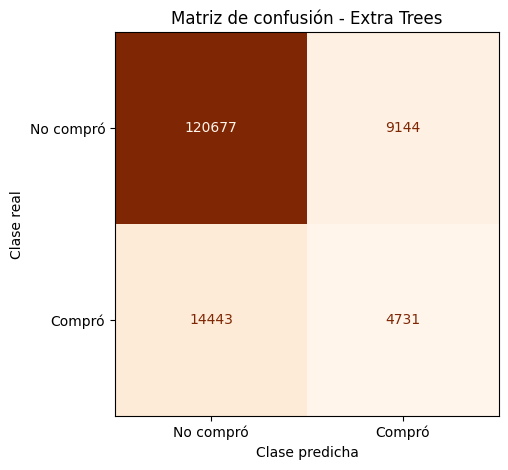

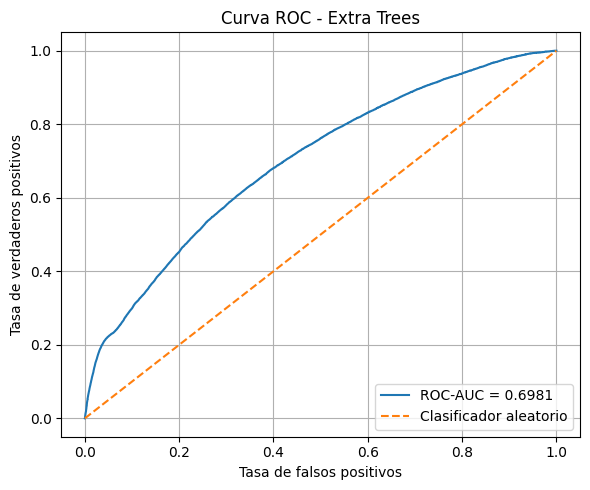

,Modelo,Accuracy_prueba,Precision_prueba,Recall_prueba,Especificidad_prueba,F1_prueba,ROC_AUC_prueba,PR_AUC_prueba,TN,FP,FN,TP
0,Extra Trees,0.841693,0.340973,0.24674,0.929565,0.286302,0.69814,0.28768,120677,9144,14443,4731



Evaluación del mejor modelo finalizada.


In [ ]:
#@title Evaluación del mejor modelo en el conjunto de prueba

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import matplotlib.pyplot as plt
import pandas as pd


# Seleccionar el mejor modelo

nombre_mejor_modelo = "Extra Trees"

modelo_final = mejores_modelos[nombre_mejor_modelo]

print(f"Evaluando mejor modelo: {nombre_mejor_modelo}")


# Predicciones sobre el conjunto de prueba de 2025

y_pred = modelo_final.predict(
    X_prueba_clasificacion
)

y_proba = modelo_final.predict_proba(
    X_prueba_clasificacion
)[:, 1]


# Matriz de confusión

matriz = confusion_matrix(
    y_prueba_clasificacion,
    y_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = matriz.ravel()


# Métricas de evaluación

accuracy = accuracy_score(
    y_prueba_clasificacion,
    y_pred
)

precision = precision_score(
    y_prueba_clasificacion,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_prueba_clasificacion,
    y_pred,
    zero_division=0
)

especificidad = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)

f1 = f1_score(
    y_prueba_clasificacion,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_prueba_clasificacion,
    y_proba
)

pr_auc = average_precision_score(
    y_prueba_clasificacion,
    y_proba
)


# Guardar resultados del mejor modelo

resultados_mejor_modelo = pd.DataFrame([{
    "Modelo": nombre_mejor_modelo,
    "Accuracy_prueba": accuracy,
    "Precision_prueba": precision,
    "Recall_prueba": recall,
    "Especificidad_prueba": especificidad,
    "F1_prueba": f1,
    "ROC_AUC_prueba": roc_auc,
    "PR_AUC_prueba": pr_auc,
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}])


predicciones_mejor_modelo = {
    "prediccion": y_pred,
    "probabilidad": y_proba
}



# Mostrar resultados
print(f"\nResultados del conjunto de prueba - {nombre_mejor_modelo}:")
print(f"Accuracy:      {accuracy:.6f}")
print(f"Precision:     {precision:.6f}")
print(f"Recall:        {recall:.6f}")
print(f"Especificidad: {especificidad:.6f}")
print(f"F1-score:      {f1:.6f}")
print(f"ROC-AUC:       {roc_auc:.6f}")
print(f"PR-AUC:        {pr_auc:.6f}")

print("\nValores de la matriz de confusión:")
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")


# Visualizar matriz de confusión

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=[
        "No compró",
        "Compró"
    ]
)

disp.plot(
    cmap="Oranges",
    values_format="d",
    colorbar=False
)

plt.title(
    f"Matriz de confusión - {nombre_mejor_modelo}"
)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()



# Curva ROC

fpr, tpr, thresholds = roc_curve(
    y_prueba_clasificacion,
    y_proba
)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.title(
    f"Curva ROC - {nombre_mejor_modelo}"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()



# Tabla resumen


display(
    resultados_mejor_modelo.round(6)
)

print("\nEvaluación del mejor modelo finalizada.")

In [ ]:
#@title Comparación entre validación cruzada y prueba final del mejor modelo

nombre_mejor_modelo = "Extra Trees"

df_comparacion_mejor_modelo = (
    df_resultados_cv.loc[
        df_resultados_cv["Modelo"] == nombre_mejor_modelo,
        [
            "Modelo",
            "Precision_CV",
            "Recall_CV",
            "F1_CV",
            "ROC_AUC_CV",
            "PR_AUC_CV"
        ]
    ]
    .merge(
        resultados_mejor_modelo[
            [
                "Modelo",
                "Precision_prueba",
                "Recall_prueba",
                "F1_prueba",
                "ROC_AUC_prueba",
                "PR_AUC_prueba"
            ]
        ],
        on="Modelo",
        how="inner"
    )
    .reset_index(drop=True)
)

display(
    df_comparacion_mejor_modelo.round(6)
)

,Modelo,Precision_CV,Recall_CV,F1_CV,ROC_AUC_CV,PR_AUC_CV,Precision_prueba,Recall_prueba,F1_prueba,ROC_AUC_prueba,PR_AUC_prueba
0,Extra Trees,0.2413,0.4703,0.3118,0.6556,0.238,0.340973,0.24674,0.286302,0.69814,0.28768


In [ ]:
#@title Exportar predicciones individuales del mejor modelo

from pathlib import Path
import numpy as np
import pandas as pd


# Columnas que identifican cada predicción
columnas_identificacion = [
    "id_cliente",
    "campaña",
    "tipo_campaña",
    "mes",
    "año"
]

# Recuperar los identificadores respetando el mismo orden del conjunto de prueba
df_predicciones_individuales = (
    df_prueba_clasificacion[
        columnas_identificacion
    ]
    .copy()
    .reset_index(drop=True)
)

# Validar que las cantidades coincidan
if len(df_predicciones_individuales) != len(y_pred):
    raise ValueError(
        "La cantidad de identificadores no coincide "
        "con la cantidad de predicciones."
    )

# Incorporar valor real, predicción y probabilidad
df_predicciones_individuales["respuesta_real"] = (
    np.asarray(y_prueba_clasificacion)
)

df_predicciones_individuales["respuesta_predicha"] = (
    np.asarray(y_pred)
)

df_predicciones_individuales["probabilidad_compra"] = (
    np.asarray(y_proba)
)

# Etiquetas descriptivas
df_predicciones_individuales["respuesta_real_texto"] = (
    df_predicciones_individuales["respuesta_real"]
    .map({
        0: "No compró",
        1: "Compró"
    })
)

df_predicciones_individuales["respuesta_predicha_texto"] = (
    df_predicciones_individuales["respuesta_predicha"]
    .map({
        0: "No comprará",
        1: "Comprará"
    })
)

# Identificar el tipo de resultado de cada observación
condiciones = [
    (
        (df_predicciones_individuales["respuesta_real"] == 1)
        & (df_predicciones_individuales["respuesta_predicha"] == 1)
    ),
    (
        (df_predicciones_individuales["respuesta_real"] == 0)
        & (df_predicciones_individuales["respuesta_predicha"] == 0)
    ),
    (
        (df_predicciones_individuales["respuesta_real"] == 0)
        & (df_predicciones_individuales["respuesta_predicha"] == 1)
    ),
    (
        (df_predicciones_individuales["respuesta_real"] == 1)
        & (df_predicciones_individuales["respuesta_predicha"] == 0)
    )
]

resultados = [
    "Verdadero positivo",
    "Verdadero negativo",
    "Falso positivo",
    "Falso negativo"
]

df_predicciones_individuales["resultado_clasificacion"] = (
    np.select(
        condiciones,
        resultados,
        default="Sin clasificar"
    )
)

# Redondear la probabilidad para facilitar su lectura
df_predicciones_individuales["probabilidad_compra"] = (
    df_predicciones_individuales["probabilidad_compra"]
    .round(6)
)

# Crear carpeta y guardar archivo
ruta_predicciones = (
    RUTA_RESULTADOS_CLASIFICACION
    / "predicciones_extra_trees_prueba_2025.csv"
)

df_predicciones_individuales.to_csv(
    ruta_predicciones,
    index=False,
    encoding="utf-8-sig"
)

print("Predicciones individuales guardadas correctamente.")
print("Ruta:", ruta_predicciones)
print("Cantidad de registros:", len(df_predicciones_individuales))

print("\nDistribución de predicciones:")
print(
    df_predicciones_individuales[
        "respuesta_predicha_texto"
    ].value_counts()
)

print("\nResultados de clasificación:")
print(
    df_predicciones_individuales[
        "resultado_clasificacion"
    ].value_counts()
)

display(
    df_predicciones_individuales.head(10)
)

Predicciones individuales guardadas correctamente.
Ruta: /content/notebook03/resultados_clasificacion/predicciones_extra_trees_prueba_2025.csv
Cantidad de registros: 148995

Distribución de predicciones:
respuesta_predicha_texto
No comprará    135120
Comprará        13875
Name: count, dtype: int64

Resultados de clasificación:
resultado_clasificacion
Verdadero negativo    120677
Falso negativo         14443
Falso positivo          9144
Verdadero positivo      4731
Name: count, dtype: int64


,id_cliente,campaña,tipo_campaña,mes,año,respuesta_real,respuesta_predicha,probabilidad_compra,respuesta_real_texto,respuesta_predicha_texto,resultado_clasificacion
0,1,Black Friday,Digital,Noviembre,2025,0,0,0.375399,No compró,No comprará,Verdadero negativo
1,1,Campaña Escolar,Escolar,Febrero,2025,0,0,0.360624,No compró,No comprará,Verdadero negativo
2,1,Campaña Escolar,Escolar,Marzo,2025,1,0,0.432359,Compró,No comprará,Falso negativo
3,1,Cyber Wow Abril,Digital,Abril,2025,0,0,0.239304,No compró,No comprará,Verdadero negativo
4,1,Cyber Wow Julio,Digital,Julio,2025,0,0,0.288276,No compró,No comprará,Verdadero negativo
5,1,Cyber Wow Noviembre,Digital,Noviembre,2025,0,0,0.203291,No compró,No comprará,Verdadero negativo
6,1,Día de la Madre,Familiar,Mayo,2025,1,0,0.309355,Compró,No comprará,Falso negativo
7,1,Día del Padre,Familiar,Junio,2025,0,0,0.287132,No compró,No comprará,Verdadero negativo
8,1,Fiestas Patrias,Festiva,Julio,2025,1,0,0.484159,Compró,No comprará,Falso negativo
9,1,Navidad,Festiva,Diciembre,2025,0,1,0.772997,No compró,Comprará,Falso positivo


In [ ]:
#@title Guardar pipeline completo del mejor modelo

from pathlib import Path
import copy
import joblib


# Crear carpeta para los modelos
ruta_modelo_clasificacion = (
    RUTA_MODELOS_CLASIFICACION
    / "extra_trees.pkl"
)

modelo_exportable = copy.deepcopy(
    modelo_final
)

modelo_exportable.memory = None

joblib.dump(
    modelo_exportable,
    ruta_modelo_clasificacion,
    compress=3
)

print("Modelo guardado correctamente.")
print("Modelo:", nombre_mejor_modelo)
print("Ruta:", ruta_modelo_clasificacion.resolve())

Modelo guardado correctamente.
Modelo: Extra Trees
Ruta: /content/notebook03/clasificacion/models/extra_trees.pkl


## 🚩 Análisis de variables

In [ ]:
#@title Preparar variables para Feature Importance y SHAP

import numpy as np
import pandas as pd

# Recuperar componentes ajustados del pipeline
preprocesador_final = modelo_final.named_steps["preprocesador"]
modelo_extra_trees = modelo_final.named_steps["modelo"]

# Nombres de todas las variables después del preprocesamiento
nombres_variables_transformadas = (
    preprocesador_final.get_feature_names_out()
)

# Recuperar el OneHotEncoder ajustado
codificador_final = (
    preprocesador_final
    .named_transformers_["categoricas"]
)

# Variables generadas mediante One-Hot Encoding
nombres_variables_categoricas = (
    codificador_final.get_feature_names_out(
        variables_categoricas
    )
)

# Relacionar cada columna codificada con su variable original
grupos_variables_categoricas = []

for variable, categorias in zip(
    variables_categoricas,
    codificador_final.categories_
):
    grupos_variables_categoricas.extend(
        [variable] * len(categorias)
    )

# Las variables numéricas conservan su nombre original
grupos_variables_originales = (
    grupos_variables_categoricas
    + variables_numericas
)

if (
    len(nombres_variables_transformadas)
    != len(grupos_variables_originales)
):
    raise ValueError(
        "La cantidad de variables transformadas no coincide "
        "con la cantidad de variables agrupadas."
    )

print("Preparación completada.")
print(
    "Cantidad de variables transformadas:",
    len(nombres_variables_transformadas)
)

print(
    "Cantidad de variables originales:",
    len(set(grupos_variables_originales))
)

Preparación completada.
Cantidad de variables transformadas: 36
Cantidad de variables originales: 12


### 💠Feature Importance

Importancia detallada:


,variable_transformada,variable_original,importancia
0,mes_Diciembre,mes,0.163111
1,campaña_Navidad,campaña,0.129752
2,tipo_campaña_Festiva,tipo_campaña,0.101793
3,tickets_previos_totales,tickets_previos_totales,0.096622
4,campañas_anteriores_con_compra,campañas_anteriores_con_compra,0.087524
5,tipo_campaña_Digital,tipo_campaña,0.040458
6,recencia_dias,recencia_dias,0.037547
7,ciudad_Lima,ciudad,0.024825
8,antiguedad_cliente_dias,antiguedad_cliente_dias,0.024486
9,campaña_Fiestas Patrias,campaña,0.019320



Importancia agrupada:


,variable_original,importancia,porcentaje_importancia
0,mes,0.217046,21.704562
1,campaña,0.204548,20.454823
2,tipo_campaña,0.166784,16.678418
3,tickets_previos_totales,0.096622,9.662182
4,campañas_anteriores_con_compra,0.087524,8.752421
5,ciudad,0.085280,8.528002
6,recencia_dias,0.037547,3.754661
7,genero,0.033111,3.311107
8,antiguedad_cliente_dias,0.024486,2.448636
9,tickets_mismo_tipo_campaña_previos,0.018751,1.875062


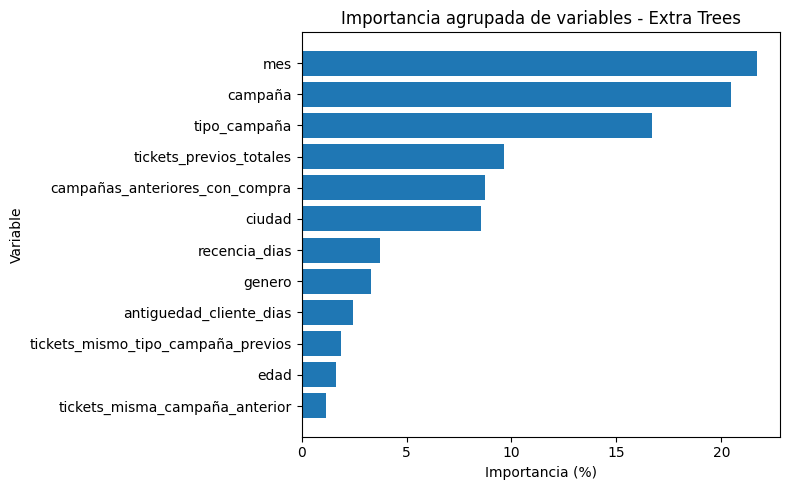

In [ ]:
#@title Feature Importance del modelo Extra Trees

import matplotlib.pyplot as plt


importancias_modelo = (
    modelo_extra_trees.feature_importances_
)

df_importancia_detallada = (
    pd.DataFrame({
        "variable_transformada": nombres_variables_transformadas,
        "variable_original": grupos_variables_originales,
        "importancia": importancias_modelo
    })
    .sort_values(
        by="importancia",
        ascending=False
    )
    .reset_index(drop=True)
)

df_importancia_agrupada = (
    df_importancia_detallada
    .groupby(
        "variable_original",
        as_index=False
    )
    .agg(
        importancia=("importancia", "sum")
    )
    .sort_values(
        by="importancia",
        ascending=False
    )
    .reset_index(drop=True)
)

df_importancia_agrupada[
    "porcentaje_importancia"
] = (
    df_importancia_agrupada["importancia"]
    * 100
)

print("Importancia detallada:")
display(
    df_importancia_detallada.head(20)
)

print("\nImportancia agrupada:")
display(
    df_importancia_agrupada
)

plt.figure(figsize=(8, 5))

plt.barh(
    df_importancia_agrupada["variable_original"],
    df_importancia_agrupada["porcentaje_importancia"]
)

plt.gca().invert_yaxis()
plt.title("Importancia agrupada de variables - Extra Trees")
plt.xlabel("Importancia (%)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### 💠Feature Importance

In [ ]:
#@title Preparar muestra de prueba para SHAP

from scipy import sparse


TAMANO_MUESTRA_SHAP = 2000

cantidad_muestra = min(
    TAMANO_MUESTRA_SHAP,
    len(X_prueba_clasificacion)
)

indices_muestra_shap = (
    X_prueba_clasificacion
    .sample(
        n=cantidad_muestra,
        random_state=SEMILLA
    )
    .index
)

X_shap_original = (
    X_prueba_clasificacion
    .loc[indices_muestra_shap]
    .copy()
)

y_shap_real = (
    y_prueba_clasificacion
    .loc[indices_muestra_shap]
    .copy()
)

# Aplicar únicamente el preprocesamiento ya ajustado
X_shap_transformado = (
    preprocesador_final.transform(
        X_shap_original
    )
)

# SHAP trabaja de forma más estable con una matriz densa
if sparse.issparse(X_shap_transformado):
    X_shap_transformado = (
        X_shap_transformado.toarray()
    )

X_shap_transformado = pd.DataFrame(
    X_shap_transformado,
    columns=nombres_variables_transformadas,
    index=X_shap_original.index
)

print("Muestra preparada correctamente.")
print("Registros utilizados:", len(X_shap_transformado))
print("Variables transformadas:", X_shap_transformado.shape[1])

print("\nDistribución de la clase en la muestra:")
print(
    y_shap_real
    .value_counts()
    .sort_index()
)

Muestra preparada correctamente.
Registros utilizados: 2000
Variables transformadas: 36

Distribución de la clase en la muestra:
respuesta_campaña
0    1774
1     226
Name: count, dtype: int64


In [ ]:
#@title Calcular valores SHAP para la clase compradora

import shap


explicador_shap = shap.TreeExplainer(
    modelo_extra_trees
)

valores_shap = explicador_shap.shap_values(
    X_shap_transformado,
    check_additivity=False
)

# Compatibilidad con diferentes versiones de SHAP
if isinstance(valores_shap, list):

    valores_shap_positivos = valores_shap[1]

else:

    valores_shap = np.asarray(
        valores_shap
    )

    if valores_shap.ndim == 3:

        valores_shap_positivos = (
            valores_shap[:, :, 1]
        )

    elif valores_shap.ndim == 2:

        valores_shap_positivos = valores_shap

    else:

        raise ValueError(
            "No se pudo reconocer la estructura "
            "de los valores SHAP."
        )

print("Valores SHAP calculados correctamente.")
print(
    "Dimensiones:",
    valores_shap_positivos.shape
)

Valores SHAP calculados correctamente.
Dimensiones: (2000, 36)


/tmp/ipykernel_1468/289256774.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


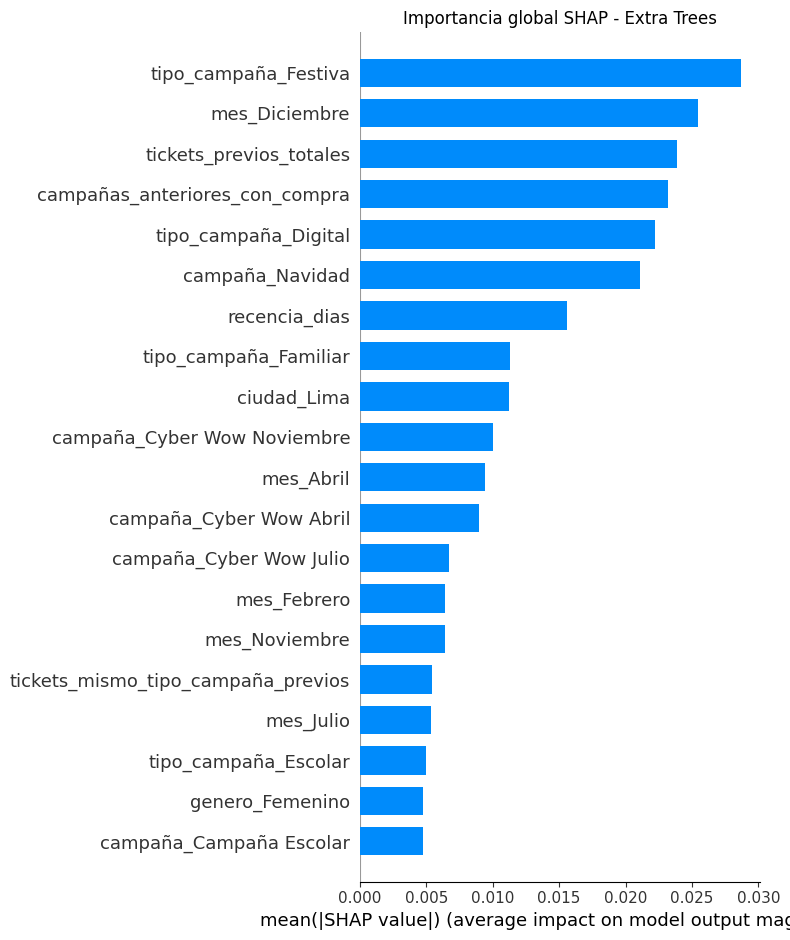

In [ ]:
#@title Importancia global SHAP

shap.summary_plot(
    valores_shap_positivos,
    X_shap_transformado,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title(
    "Importancia global SHAP - Extra Trees"
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1468/3454373146.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


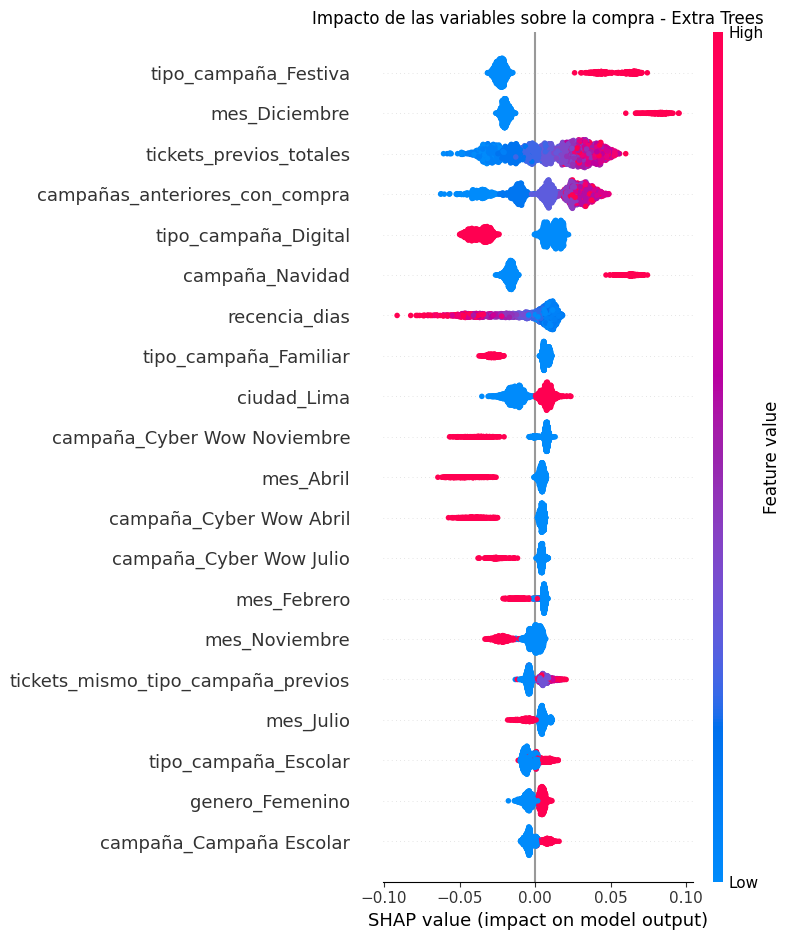

In [ ]:
#@title Distribución del impacto SHAP

shap.summary_plot(
    valores_shap_positivos,
    X_shap_transformado,
    max_display=20,
    show=False
)

plt.title(
    "Impacto de las variables sobre la compra - Extra Trees"
)

plt.tight_layout()
plt.show()

Importancia SHAP detallada:


,variable_transformada,variable_original,importancia_shap
0,tipo_campaña_Festiva,tipo_campaña,0.028666
1,mes_Diciembre,mes,0.025497
2,tickets_previos_totales,tickets_previos_totales,0.023888
3,campañas_anteriores_con_compra,campañas_anteriores_con_compra,0.023214
4,tipo_campaña_Digital,tipo_campaña,0.022254
5,campaña_Navidad,campaña,0.021072
6,recencia_dias,recencia_dias,0.015589
7,tipo_campaña_Familiar,tipo_campaña,0.011316
8,ciudad_Lima,ciudad,0.011194
9,campaña_Cyber Wow Noviembre,campaña,0.009983



Importancia SHAP agrupada:


,variable_original,importancia_shap,porcentaje_importancia_shap
0,tipo_campaña,0.067199,22.353958
1,campaña,0.063772,21.213803
2,mes,0.062843,20.904742
3,tickets_previos_totales,0.023888,7.946387
4,campañas_anteriores_con_compra,0.023214,7.722270
5,ciudad,0.019293,6.417914
6,recencia_dias,0.015589,5.185697
7,genero,0.010358,3.445463
8,tickets_mismo_tipo_campaña_previos,0.005391,1.793188
9,antiguedad_cliente_dias,0.004569,1.519795


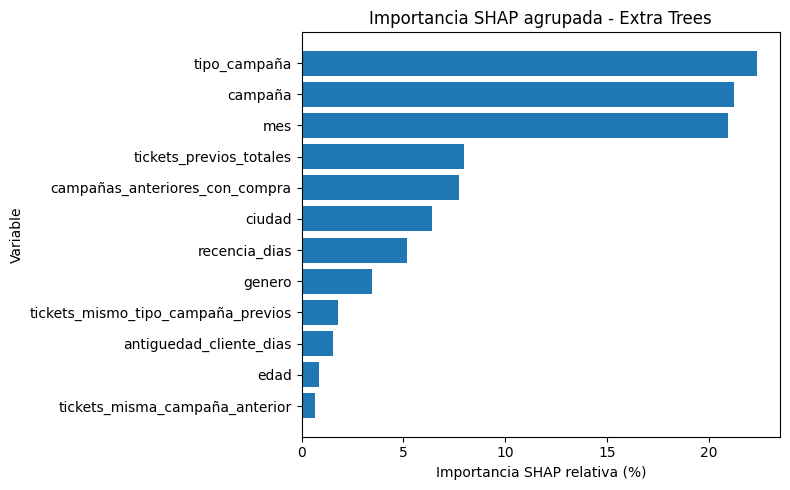

In [ ]:
#@title Importancia SHAP agrupada

importancia_shap_promedio = (
    np.abs(valores_shap_positivos)
    .mean(axis=0)
)

df_importancia_shap_detallada = (
    pd.DataFrame({
        "variable_transformada": nombres_variables_transformadas,
        "variable_original": grupos_variables_originales,
        "importancia_shap": importancia_shap_promedio
    })
    .sort_values(
        by="importancia_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

df_importancia_shap_agrupada = (
    df_importancia_shap_detallada
    .groupby(
        "variable_original",
        as_index=False
    )
    .agg(
        importancia_shap=(
            "importancia_shap",
            "sum"
        )
    )
    .sort_values(
        by="importancia_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

total_importancia_shap = (
    df_importancia_shap_agrupada[
        "importancia_shap"
    ].sum()
)

df_importancia_shap_agrupada[
    "porcentaje_importancia_shap"
] = (
    df_importancia_shap_agrupada[
        "importancia_shap"
    ]
    / total_importancia_shap
    * 100
)

print("Importancia SHAP detallada:")
display(
    df_importancia_shap_detallada.head(20)
)

print("\nImportancia SHAP agrupada:")
display(
    df_importancia_shap_agrupada
)

plt.figure(figsize=(8, 5))

plt.barh(
    df_importancia_shap_agrupada[
        "variable_original"
    ],
    df_importancia_shap_agrupada[
        "porcentaje_importancia_shap"
    ]
)

plt.gca().invert_yaxis()
plt.title("Importancia SHAP agrupada - Extra Trees")
plt.xlabel("Importancia SHAP relativa (%)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [ ]:
#@title Guardar resultados de Feature Importance y SHAP

from pathlib import Path


ruta_importancia_detallada = (
    RUTA_RESULTADOS_CLASIFICACION
    / "importancia_detallada_extra_trees.csv"
)

ruta_importancia_agrupada = (
    RUTA_RESULTADOS_CLASIFICACION
    / "importancia_agrupada_extra_trees.csv"
)

ruta_shap_detallada = (
    RUTA_RESULTADOS_CLASIFICACION
    / "importancia_shap_detallada_extra_trees.csv"
)

ruta_shap_agrupada = (
    RUTA_RESULTADOS_CLASIFICACION
    / "importancia_shap_agrupada_extra_trees.csv"
)

df_importancia_detallada.to_csv(
    ruta_importancia_detallada,
    index=False,
    encoding="utf-8-sig"
)

df_importancia_agrupada.to_csv(
    ruta_importancia_agrupada,
    index=False,
    encoding="utf-8-sig"
)

df_importancia_shap_detallada.to_csv(
    ruta_shap_detallada,
    index=False,
    encoding="utf-8-sig"
)

df_importancia_shap_agrupada.to_csv(
    ruta_shap_agrupada,
    index=False,
    encoding="utf-8-sig"
)

print("Resultados guardados correctamente.")
print("Feature Importance detallada:", ruta_importancia_detallada)
print("Feature Importance agrupada:", ruta_importancia_agrupada)
print("SHAP detallado:", ruta_shap_detallada)
print("SHAP agrupado:", ruta_shap_agrupada)

Resultados guardados correctamente.
Feature Importance detallada: /content/notebook03/clasificacion/resultados/importancia_detallada_extra_trees.csv
Feature Importance agrupada: /content/notebook03/clasificacion/resultados/importancia_agrupada_extra_trees.csv
SHAP detallado: /content/notebook03/clasificacion/resultados/importancia_shap_detallada_extra_trees.csv
SHAP agrupado: /content/notebook03/clasificacion/resultados/importancia_shap_agrupada_extra_trees.csv


**Interpretación**

El análisis de Feature Importance y SHAP muestra que la probabilidad de compra estuvo influida principalmente por el momento y el tipo de campaña, especialmente por diciembre, Navidad y las campañas festivas, mientras que el historial del cliente, como sus tickets previos, participación en campañas anteriores y recencia de compra, también tuvo un peso importante. En términos de negocio, esto indica que AndinaRetail podría concentrar mayores esfuerzos comerciales en campañas de fin de año y priorizar a clientes que compraron recientemente o que ya respondieron a promociones anteriores, ya que presentan una mayor probabilidad de volver a comprar. En cambio, los clientes con poco historial o muchos días desde su última compra podrían requerir estrategias de reactivación más específicas. Estos resultados deben entenderse como asociaciones utilizadas por el modelo y no como relaciones de causa directa.

## 🚩 Conclusiones

**Conclusiones**
1. El modelo Extra Trees permitió identificar diferencias claras entre clientes con mayor y menor probabilidad de comprar durante una campaña, por lo que puede apoyar la priorización comercial antes del inicio de cada promoción.
2. Las predicciones mostraron que el comportamiento histórico del cliente aporta información relevante. Los clientes con compras recientes, más tickets previos o participación en campañas anteriores tienden a presentar una mayor probabilidad de respuesta.
3. El momento y el tipo de campaña influyen de manera importante en la decisión de compra. Las campañas festivas y de fin de año presentan patrones distintos frente a campañas digitales o realizadas en otros meses.
4. El modelo no debe utilizarse únicamente para decidir quién recibirá una campaña, sino como una herramienta de apoyo para ordenar a los clientes según su probabilidad estimada y utilizar mejor los recursos comerciales.
5. Aunque el modelo logra anticipar una parte importante de las respuestas, todavía pueden existir falsos positivos y falsos negativos. Por ello, las predicciones deben complementarse con criterios de marketing, disponibilidad de inventario y objetivos de cada campaña.

**Recomendaciones**
1. Se recomienda clasificar a los clientes por niveles de probabilidad de compra, de modo que los clientes con mayor puntuación reciban acciones orientadas a la conversión y los de menor puntuación estrategias de reactivación o fidelización.
2. AndinaRetail debería asignar mayores esfuerzos de comunicación y presupuesto a las campañas y periodos que presentan una mayor respuesta esperada, especialmente cuando coinciden con clientes que ya tienen un historial activo de compras.
3. Para reducir el envío de promociones a clientes con baja posibilidad de respuesta, se recomienda definir un umbral de decisión según el costo de contactar a un cliente y el beneficio esperado de lograr una compra.
4. El modelo debería actualizarse periódicamente con nuevas campañas y transacciones, ya que los hábitos de compra pueden cambiar con el tiempo y afectar la calidad de las predicciones futuras.
5. Se recomienda evaluar los resultados reales después de cada campaña y comparar las compras observadas con las probabilidades estimadas, con el fin de detectar cambios en el comportamiento, ajustar el umbral y mejorar el modelo.